# Physical Track Analysis — SLSNe Detection with Rubin LSST

Parallel to `analysis_multimodel_comparison.ipynb` (GP track).
Physical templates use MOSFiT posteriors (Gómez+2024), full SED synthesis via `synthesize_mag_at_z()`. Valid z=0.1–5.0.

GP canonical runs (260409) are untouched by this notebook.

**Reload flags:** Templates NO — Population NO — Mag grid NO (not used in physical path)

In [1]:
# ============================================================================
# CELL 1: Setup and configuration
# ============================================================================
import sys, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import healpy as hp
from pathlib import Path
from importlib import reload

# --- Repo path ---
REPO = Path('/users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric')
sys.path.insert(0, str(REPO / 'py_files'))
from slsn_metrics.paths import get_shared_output_dir, get_output_dir, get_rate_csv_path
import slsn_metrics.diagnostics as diag_mod
reload(diag_mod)
from slsn_metrics.diagnostics import (
    plot_population_rate_vs_redshift,
    plot_healpix_efficiency,
)

# --- Configuration ---
MODELS = [
    'naive_physical',
    'o_dependent_physical',
    'fe_dependent_physical',
]
CADENCES = [
    'baseline_v5.1.1_10yrs',
    'baseline_v5.3.0_10yrs',
    'noroll_v5.0.0_10yrs',
    'poor_weather_v5.0.1_10yrs',
]
SURVEY_YEARS = 10
Z_MIN, Z_MAX = 0.1, 5.0

# --- Paths ---
SHARED_DIR   = get_shared_output_dir('SLSNe')
ADAPTIVE_DIR = REPO / 'output/SLSNe/adaptive'

# --- Load adaptive efficiency results ---
# Each model has one adaptive_results.csv with columns:
#   z_lo, z_hi, cadence, metric, n_events, n_success, efficiency, sigma
print('=== Adaptive Results Check ===')
ADAPTIVE = {}
for model in MODELS:
    csv = ADAPTIVE_DIR / f'{model}_adaptive_results.csv'
    if csv.exists():
        df = pd.read_csv(csv)
        ADAPTIVE[model] = df
        zmax = df['z_hi'].max()
        n_bins = df['z_hi'].nunique()
        print(f'  OK  {model}: {n_bins} z-bins, z_max={zmax:.1f}')
    else:
        print(f'  MISSING  {model}: {csv}')

print(f'\nLoaded {len(ADAPTIVE)}/{len(MODELS)} adaptive result files')
#

=== Adaptive Results Check ===
  OK  naive_physical: 14 z-bins, z_max=1.5
  OK  o_dependent_physical: 14 z-bins, z_max=1.5
  OK  fe_dependent_physical: 16 z-bins, z_max=1.7

Loaded 3/3 adaptive result files


✓ Saved rate evolution plot → /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/rate_evolution_comparison_physical.png


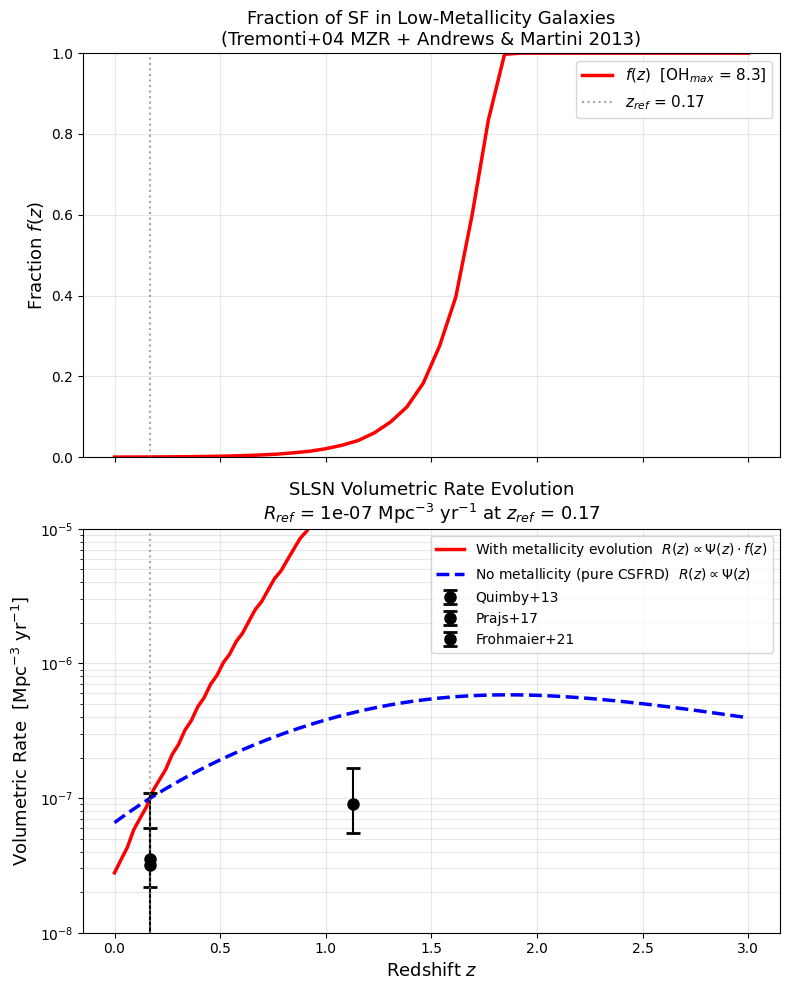

Saved: rate_evolution_comparison_physical.png


In [2]:
# ============================================================================
# CELL A: Rate evolution comparison — analytical R(z) curves (model-agnostic)
# Shows SFR x metallicity fraction vs pure-SFR curve + observed measurements.
# No population needed — call once for all models.
# ============================================================================
reload(diag_mod)
from slsn_metrics.diagnostics import plot_rate_evolution_comparison

out_rate_fig = get_output_dir('SLSNe') / 'rate_evolution_comparison_physical.png'
plot_rate_evolution_comparison(save_path=out_rate_fig)
print(f'Saved: {out_rate_fig.name}')


In [3]:
# ============================================================================
# CELL 6: Build per-model efficiency data from adaptive results CSV
# No population pkl or .npy loading needed — adaptive CSV has everything.
# Builds pop_data dict compatible with downstream plotting cells.
# ============================================================================

METRIC_MAP = {
    'detect':       'SLSN_Detect_Physical_Metric',
    'characterize': 'SLSN_Characterize_Physical_Metric',
    'villar':       'SLSN_Villar_Physical_Metric',
    'elasticc':     'SLSN_ELAsTiCC_Metric',
    'spectrigger':  'SLSN_SpecTrigger_Physical_Metric',
}
METRIC_KEYS = list(METRIC_MAP.keys())

pop_data = {}

for model in MODELS:
    if model not in ADAPTIVE:
        print(f'Skipping {model} — no adaptive results')
        continue

    df = ADAPTIVE[model]
    print(f'\n{model}:')

    metric_arrays = {m: {} for m in METRIC_KEYS}
    z_bins = sorted(df[['z_lo','z_hi']].drop_duplicates().values.tolist())

    for short, full in METRIC_MAP.items():
        for cadence in CADENCES:
            sub = df[(df['metric']==full) & (df['cadence']==cadence)].copy()
            if sub.empty:
                metric_arrays[short][cadence] = None
                continue
            # Use z_lo+z_hi as lookup keys — one row per z-bin per cadence
            eff_dict = dict(zip(
                zip(sub['z_lo'], sub['z_hi']),
                sub['efficiency']
            ))
            n_dict = dict(zip(
                zip(sub['z_lo'], sub['z_hi']),
                sub['n_events']
            ))
            metric_arrays[short][cadence] = {
                'z_bins':     [(z0,z1) for z0,z1 in z_bins],
                'efficiency': [float(eff_dict.get((z0,z1), np.nan)) for z0,z1 in z_bins],
                'n_events':   [int(n_dict.get((z0,z1), 0))          for z0,z1 in z_bins],
            }

    z_lo_arr  = np.array([b[0] for b in z_bins])
    z_hi_arr  = np.array([b[1] for b in z_bins])
    z_centers = 0.5 * (z_lo_arr + z_hi_arr)

    pop_data[model] = {
        'z_bins':      z_bins,
        'z_lo':        z_lo_arr,
        'z_hi':        z_hi_arr,
        'z_centers':   z_centers,
        'detect':       metric_arrays['detect'],
        'characterize': metric_arrays['characterize'],
        'spectrigger':  metric_arrays['spectrigger'],
        'villar':       metric_arrays['villar'],
        'elasticc':     metric_arrays['elasticc'],
    }
    print(f'  z-bins: {len(z_bins)}, cadences with data: {CADENCES}')

print('\n=== Adaptive efficiency data loaded for all models ===')



naive_physical:
  z-bins: 14, cadences with data: ['baseline_v5.1.1_10yrs', 'baseline_v5.3.0_10yrs', 'noroll_v5.0.0_10yrs', 'poor_weather_v5.0.1_10yrs']

o_dependent_physical:
  z-bins: 14, cadences with data: ['baseline_v5.1.1_10yrs', 'baseline_v5.3.0_10yrs', 'noroll_v5.0.0_10yrs', 'poor_weather_v5.0.1_10yrs']

fe_dependent_physical:
  z-bins: 16, cadences with data: ['baseline_v5.1.1_10yrs', 'baseline_v5.3.0_10yrs', 'noroll_v5.0.0_10yrs', 'poor_weather_v5.0.1_10yrs']

=== Adaptive efficiency data loaded for all models ===


Loading physical templates...
[load_magnitude_grid] Loaded with filters: ['u', 'g', 'r', 'i', 'z', 'y'], shape=(265, 100, 79), convention=apparent ✓
Templates loaded: 265 events

=== Population diagnostics: naive_physical ===
[LOAD] Loaded 2032193 SLSNe from /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/shared/population_naive_physical.pkl
[LOAD] z-filtered to 750348 events (z_min=0.1, z_max=2.0)


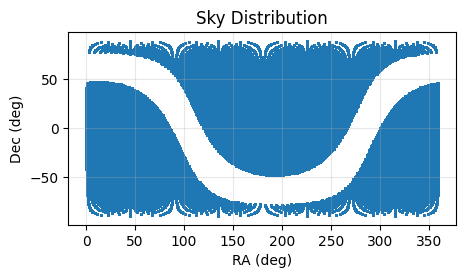

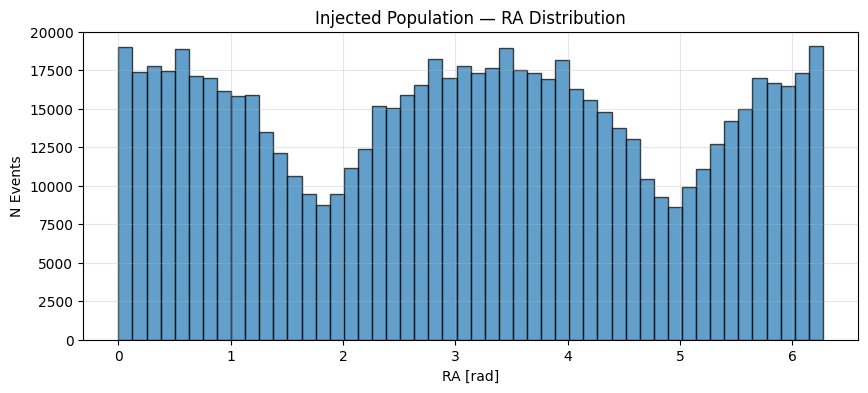

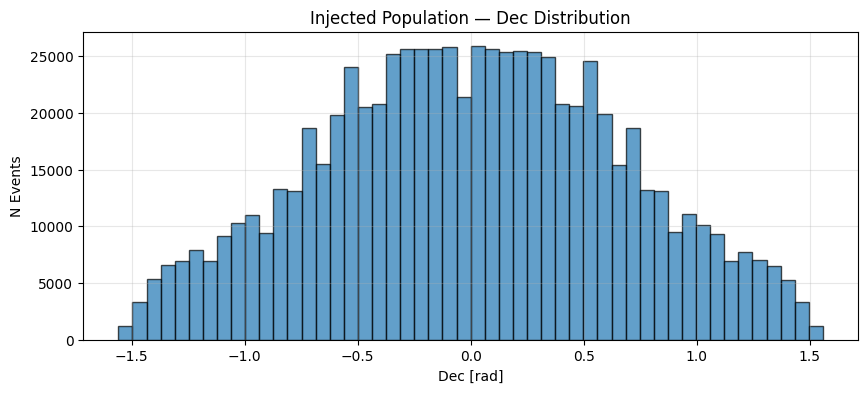

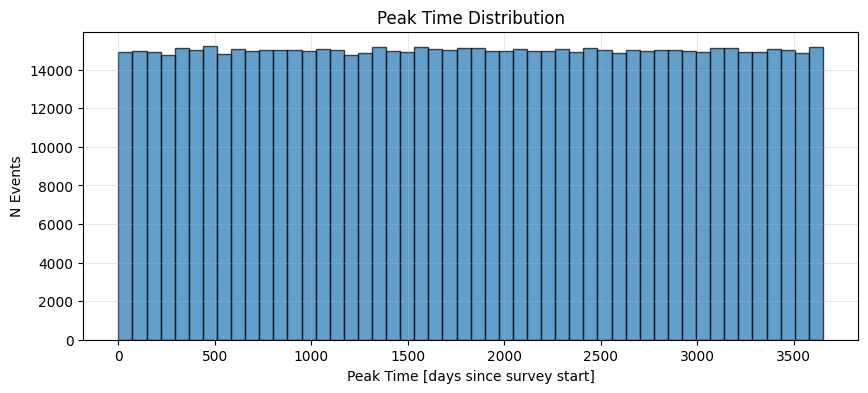

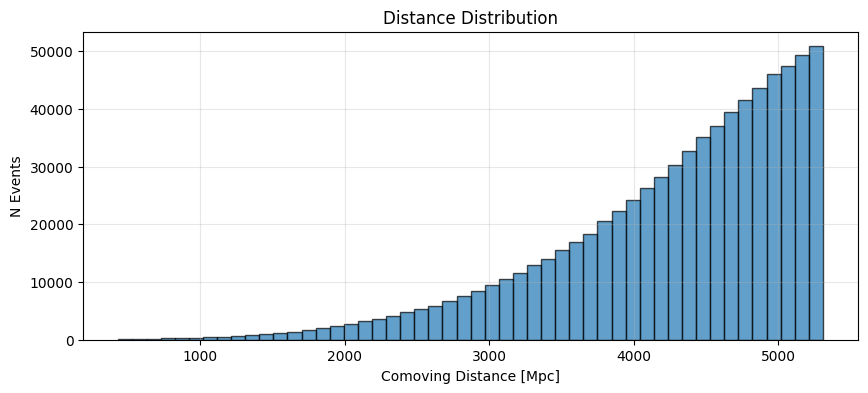

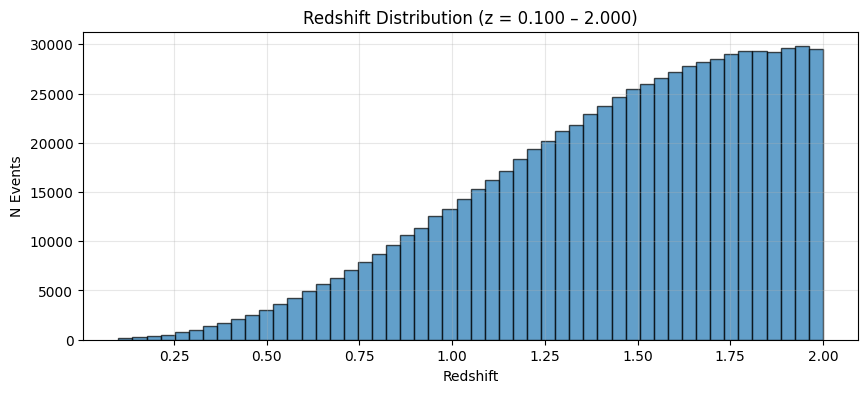

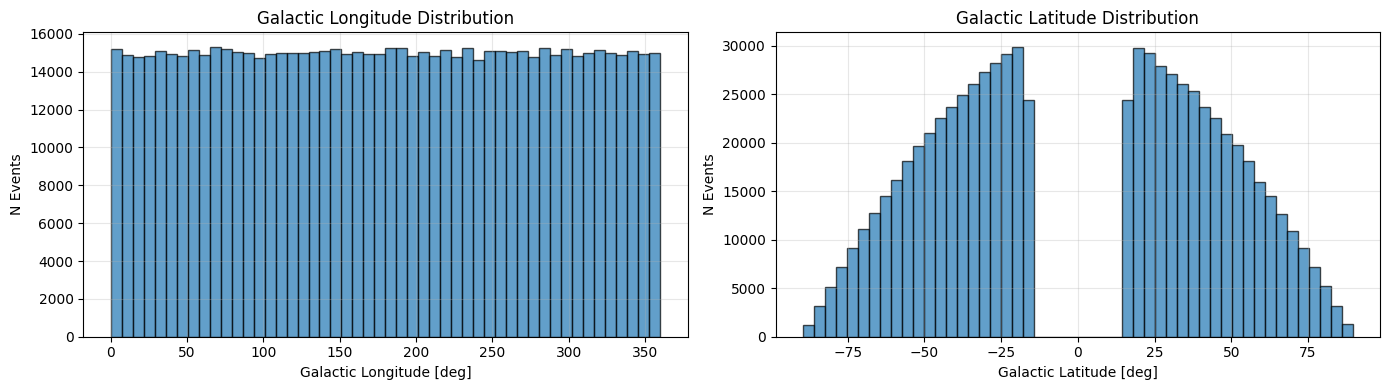

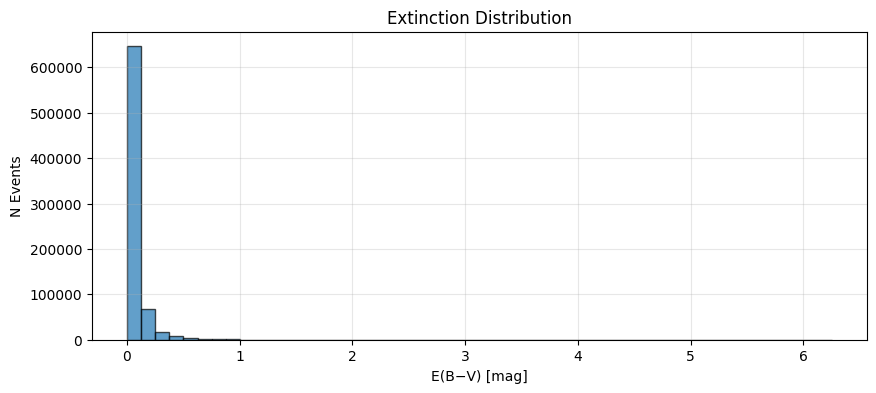

  Diagnostics saved to /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/naive_physical

=== Population diagnostics: o_dependent_physical ===
[LOAD] Loaded 7035974 SLSNe from /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/shared/population_o_dependent_physical.pkl
[LOAD] z-filtered to 1144460 events (z_min=0.1, z_max=2.0)


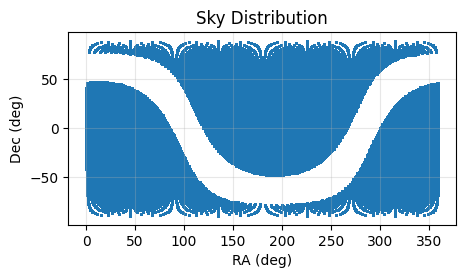

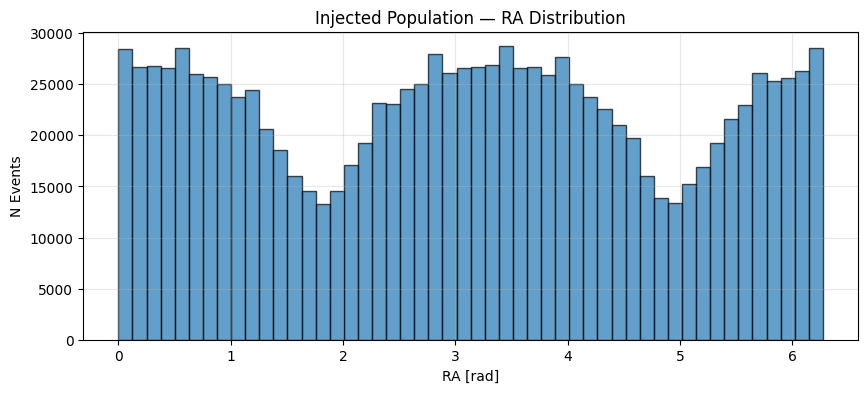

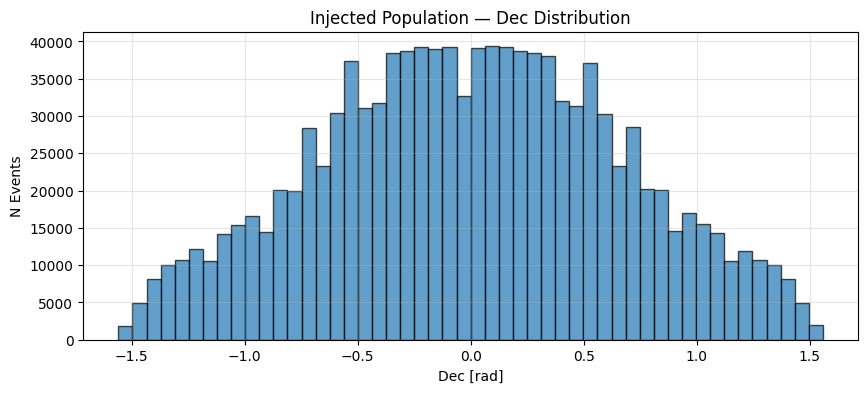

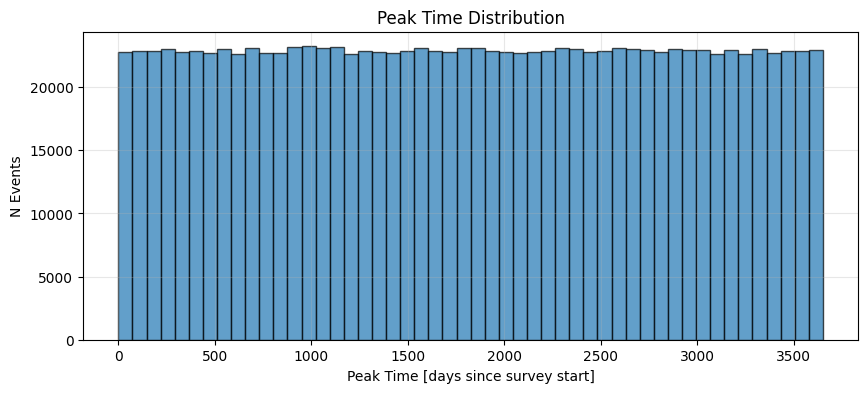

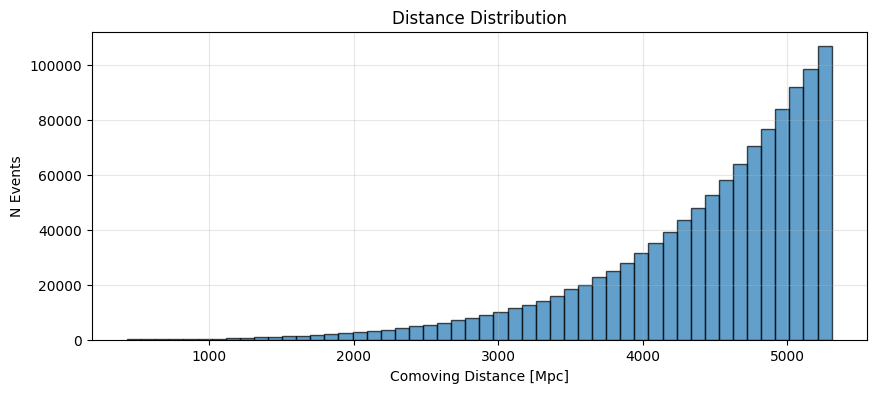

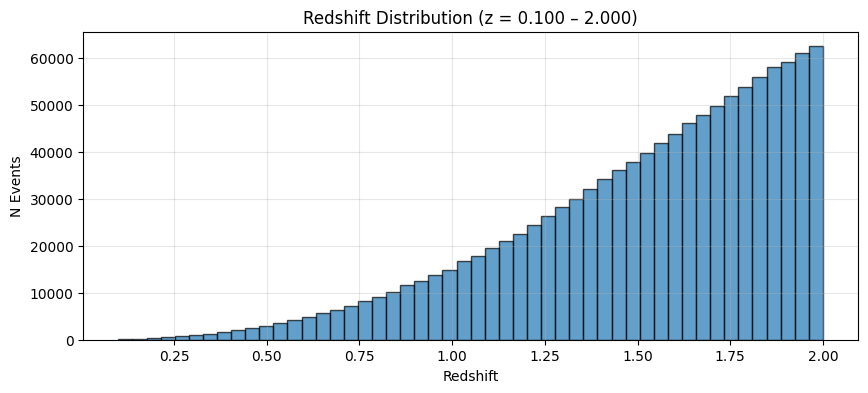

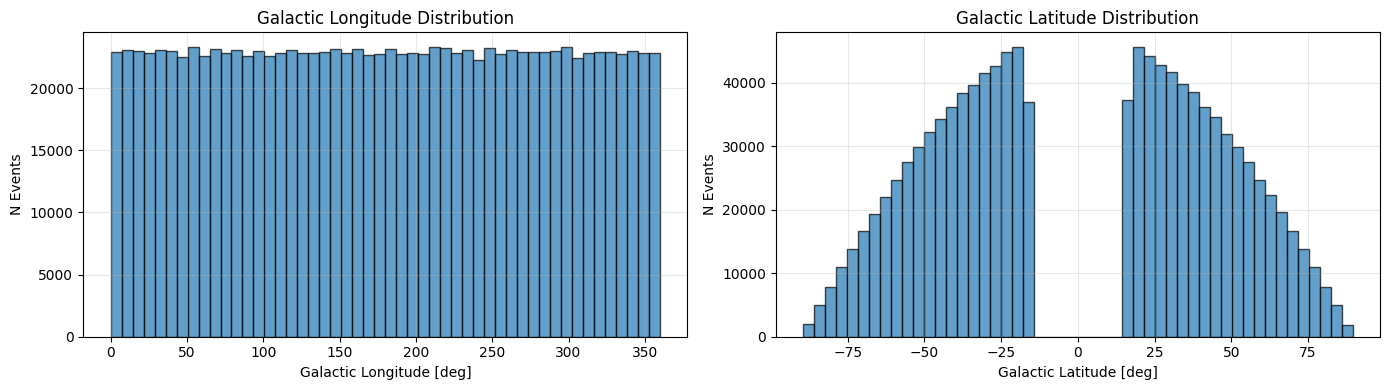

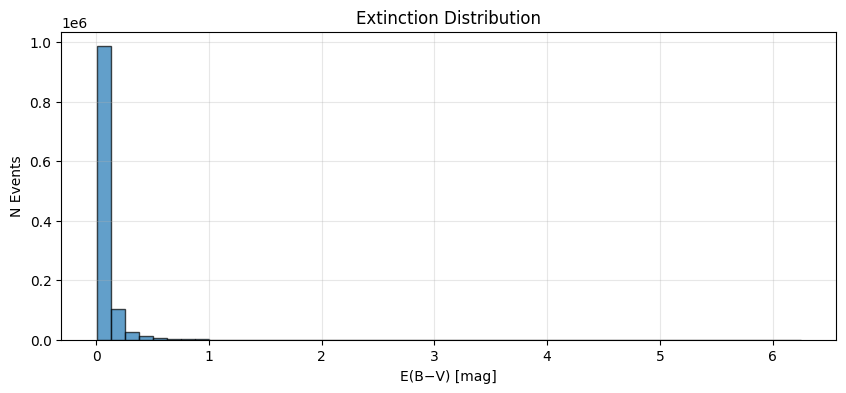

  Diagnostics saved to /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/o_dependent_physical

=== Population diagnostics: fe_dependent_physical ===
[LOAD] Loaded 14424192 SLSNe from /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/shared/population_fe_dependent_physical.pkl
[LOAD] z-filtered to 2237360 events (z_min=0.1, z_max=2.0)


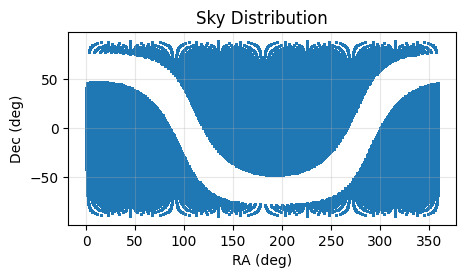

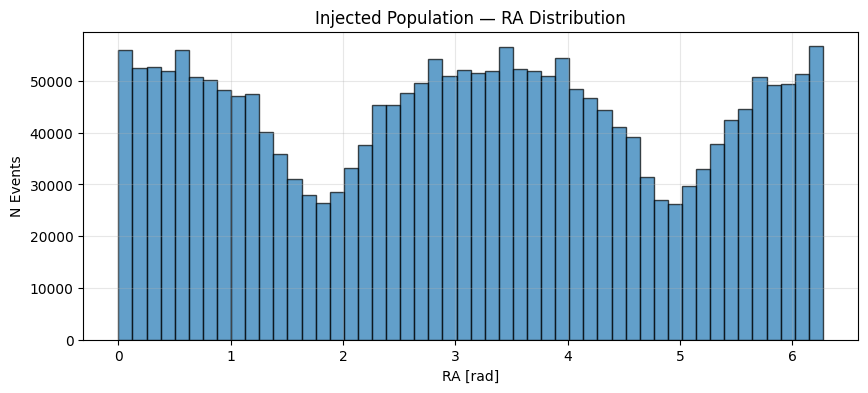

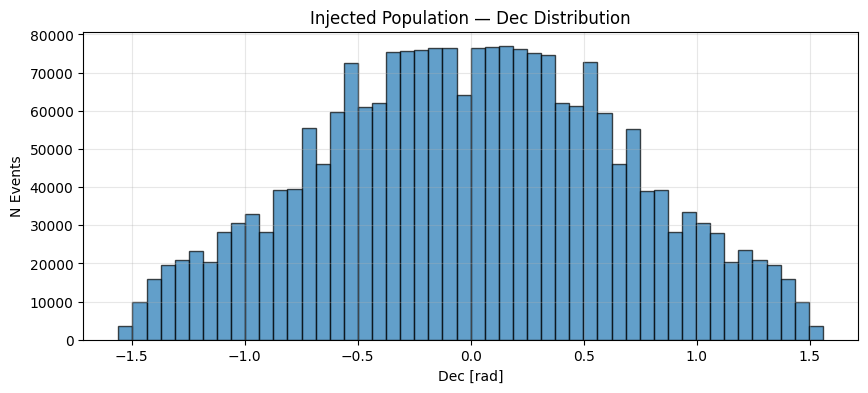

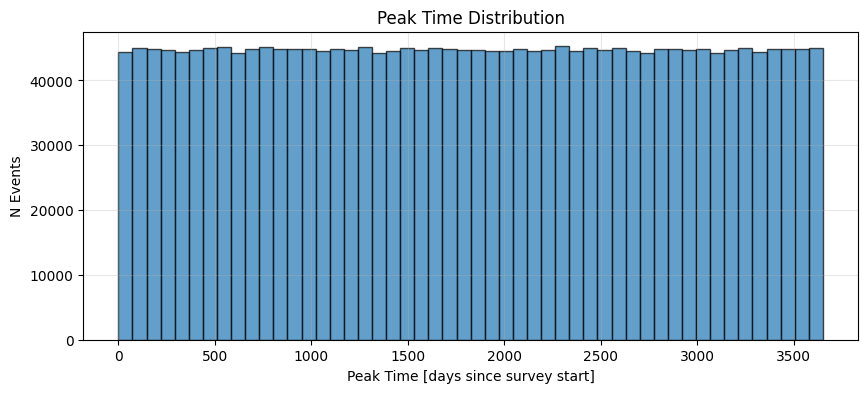

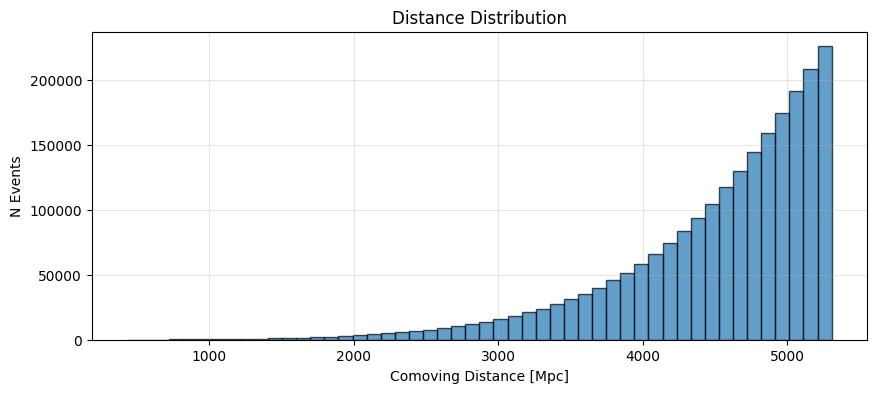

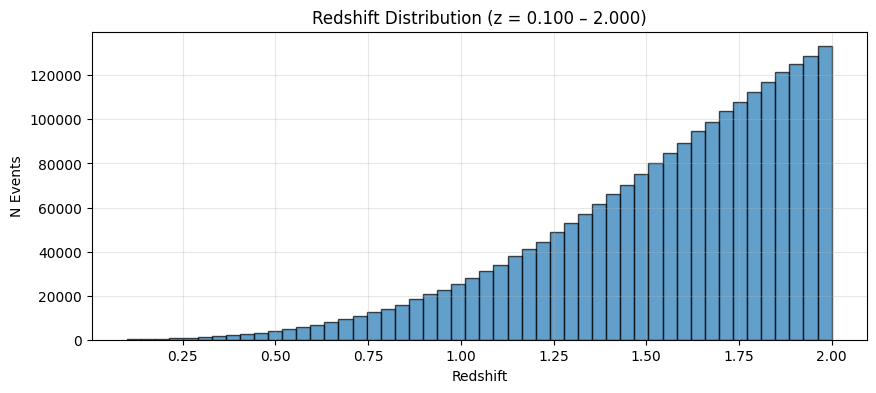

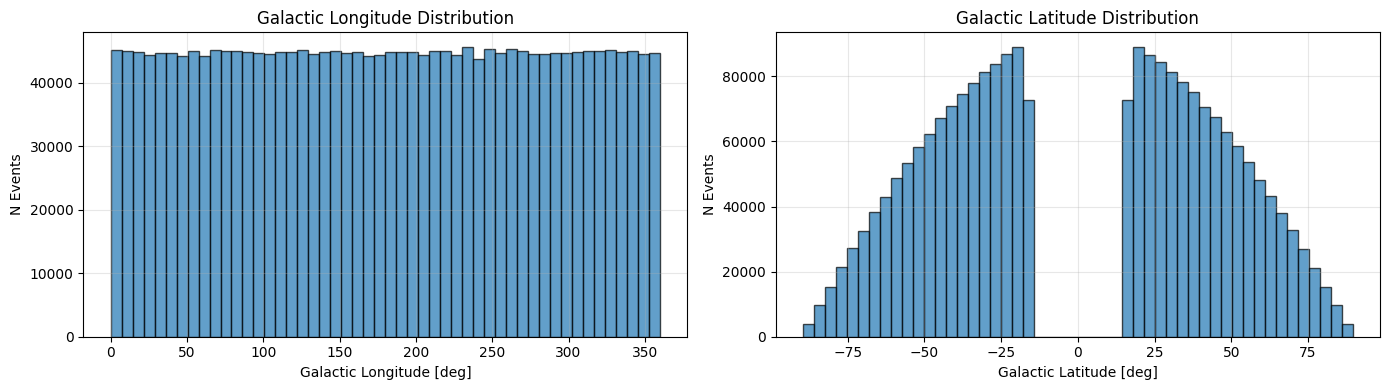

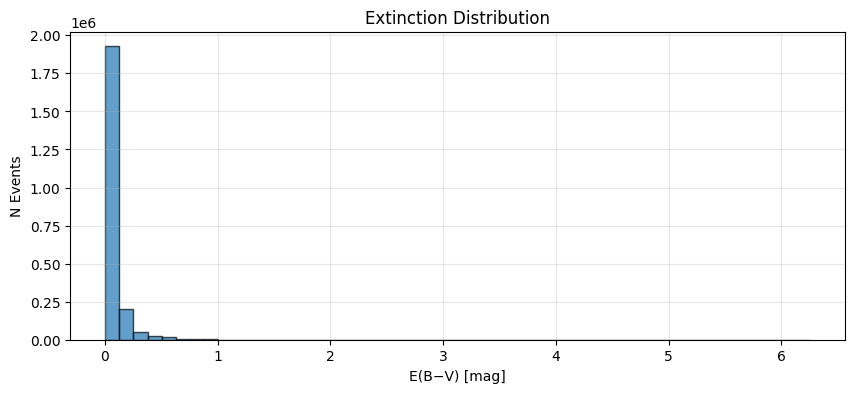

  Diagnostics saved to /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/fe_dependent_physical

=== Population diagnostics complete ===


In [4]:
# ============================================================================
# CELL B: Population diagnostics — all 3 models
# Loads templates and population slicers for diagnostics.
# Also caches pop_slicers dict for Cells C and D.
# ============================================================================
from slsn_metrics.model import LC
from slsn_metrics.population import generate_SLSN_PopSlicer
reload(diag_mod)
from slsn_metrics.diagnostics import plot_population_diagnostics

# Load templates (needed by generate_SLSN_PopSlicer)
print('Loading physical templates...')
templates = LC(load_from=str(SHARED_DIR / 'physical_templates.pkl'))
templates.load_magnitude_grid(str(SHARED_DIR / 'physical_mag_grid.pkl'))
print(f'Templates loaded: {len(templates.sed_grid)} events')

pop_slicers = {}

for model in MODELS:
    print(f'\n=== Population diagnostics: {model} ===')
    pop_pkl   = SHARED_DIR / f'population_{model}.pkl'
    model_dir = get_output_dir('SLSNe', subdir=model)

    pop = generate_SLSN_PopSlicer(
        lc_model=templates,
        load_from=str(pop_pkl),
        make_debug_plots=False
    )
    pop_slicers[model] = pop
    sp = pop.slice_points

    plot_population_diagnostics(
        ra_rad        = sp['ra'],
        dec_rad       = sp['dec'],
        peak_times    = sp['peak_time'],
        distances_mpc = sp['distance'],
        z_vals        = sp['z'],
        ebv           = sp.get('ebv', None),
        gall          = sp.get('gall', None),
        galb          = sp.get('galb', None),
        outdir        = str(model_dir),
        prefix        = f'population_{model}'
    )
    print(f'  Diagnostics saved to {model_dir}')

print('\n=== Population diagnostics complete ===')


In [5]:
# ============================================================================
# CELL 2: Build combined DataFrame from adaptive results
# Columns: z_lo, z_hi, cadence, metric, n_events, n_success, efficiency,
#          sigma, model, per_year, cadence_short, model_label
# ============================================================================

cadence_labels = {
    'baseline_v5.1.1_10yrs':    'baseline v5.1.1',
    'baseline_v5.3.0_10yrs':    'baseline v5.3.0',
    'noroll_v5.0.0_10yrs':      'noroll',
    'poor_weather_v5.0.1_10yrs':'poor_weather',
}
model_labels = {
    'fe_dependent_physical': 'Fe-dependent (Physical)',
    'o_dependent_physical':  'O-dependent (Physical)',
    'naive_physical':        'Naive SFR (Physical)',
}

rows = []
for model, df_adap in ADAPTIVE.items():
    df_s = df_adap.copy()
    df_s['model']    = model
    df_s['per_year'] = df_s['n_success'] / SURVEY_YEARS
    rows.append(df_s)

df_all = pd.concat(rows, ignore_index=True)
df_all['cadence_short'] = df_all['cadence'].map(cadence_labels)
df_all['model_label']   = df_all['model'].map(model_labels)

print(f'Loaded {len(df_all)} rows across {df_all["model"].nunique()} models')
print(f'Metrics present: {df_all["metric"].unique().tolist()}')
print(f'Cadences present: {df_all["cadence"].unique().tolist()}')
print(f'Z-bins: {df_all["z_lo"].nunique()} unique bins')
print(f'\nSample rows:')
print(df_all[df_all['metric']=='SLSN_ELAsTiCC_Metric'].head(4).to_string())

Loaded 3530 rows across 3 models
Metrics present: ['SLSN_Detect_Physical_Metric', 'SLSN_Characterize_Physical_Metric', 'SLSN_Villar_Physical_Metric', 'SLSN_ELAsTiCC_Metric', 'SLSN_SpecTrigger_Physical_Metric']
Cadences present: ['poor_weather_v5.0.1_10yrs', 'baseline_v5.3.0_10yrs', 'noroll_v5.0.0_10yrs', 'baseline_v5.1.1_10yrs']
Z-bins: 16 unique bins

Sample rows:
                      cadence                metric  n_events  n_success  efficiency  z_lo  z_hi     sigma           model  per_year    cadence_short           model_label
3   poor_weather_v5.0.1_10yrs  SLSN_ELAsTiCC_Metric       585        300    0.512821   0.1   0.2  0.020666  naive_physical      30.0     poor_weather  Naive SFR (Physical)
8       baseline_v5.3.0_10yrs  SLSN_ELAsTiCC_Metric       585        316    0.540171   0.1   0.2  0.020606  naive_physical      31.6  baseline v5.3.0  Naive SFR (Physical)
13        noroll_v5.0.0_10yrs  SLSN_ELAsTiCC_Metric       585        321    0.548718   0.1   0.2  0.020574  naive_ph

In [6]:
# ============================================================================
# CELL 3: Summary table — detections/yr and efficiency, all combinations
# Sums n_success across all z-bins per model × cadence × metric
# ============================================================================

METRIC_NAMES = {
    'SLSN_Detect_Physical_Metric':       'Detect',
    'SLSN_Characterize_Physical_Metric': 'Characterize',
    'SLSN_Villar_Physical_Metric':       'Villar',
    'SLSN_ELAsTiCC_Metric':              'ELAsTiCC',
    'SLSN_SpecTrigger_Physical_Metric':  'SpecTrigger',
}

# Aggregate across z-bins: sum n_success, sum n_events per model×cadence×metric
agg = df_all.groupby(['model_label', 'cadence_short', 'metric']).agg(
    n_success=('n_success', 'sum'),
    n_events=('n_events',  'sum'),
).reset_index()
agg['per_year']   = agg['n_success'] / SURVEY_YEARS
agg['efficiency'] = agg['n_success'] / agg['n_events']
agg['metric_short'] = agg['metric'].map(METRIC_NAMES)

CADENCE_ORDER = ['baseline v5.1.1', 'baseline v5.3.0', 'noroll', 'poor_weather']
MODEL_ORDER   = ['Naive SFR (Physical)', 'O-dependent (Physical)', 'Fe-dependent (Physical)']

for metric_full, metric_short in METRIC_NAMES.items():
    sub = agg[agg['metric'] == metric_full]
    if sub.empty:
        print(f'No data for {metric_short}')
        continue

    pivot = sub.pivot_table(
        index='model_label',
        columns='cadence_short',
        values='per_year',
        aggfunc='first'
    ).reindex(index=MODEL_ORDER, columns=CADENCE_ORDER)

    print(f'\n=== {metric_short} — detections per year ===')
    print(pivot.round(1).to_string())

# Overall efficiency summary for Detect
print('\n=== Detect — overall efficiency [%] (all z-bins combined) ===')
det = agg[agg['metric'] == 'SLSN_Detect_Physical_Metric']
pivot_eff = det.pivot_table(
    index='model_label',
    columns='cadence_short',
    values='efficiency',
    aggfunc='first'
).reindex(index=MODEL_ORDER, columns=CADENCE_ORDER) * 100
print(pivot_eff.round(3).to_string())


=== Detect — detections per year ===
cadence_short            baseline v5.1.1  baseline v5.3.0  noroll  poor_weather
model_label                                                                    
Naive SFR (Physical)              2081.4           2107.8   769.6         600.0
O-dependent (Physical)            2049.6           2079.0   771.6         594.2
Fe-dependent (Physical)           2469.0           2470.2   919.8         720.8

=== Characterize — detections per year ===
cadence_short            baseline v5.1.1  baseline v5.3.0  noroll  poor_weather
model_label                                                                    
Naive SFR (Physical)              1403.4           1406.2   535.6         395.6
O-dependent (Physical)            1388.4           1390.8   529.2         394.0
Fe-dependent (Physical)           1628.4           1627.2   618.4         455.0

=== Villar — detections per year ===
cadence_short            baseline v5.1.1  baseline v5.3.0  noroll  poor_weather


In [7]:
# ============================================================================
# CELL C: Simulated vs observed rates — all 3 models
# Reuses pop_slicers cached by Cell B (no reload needed).
# ============================================================================
reload(diag_mod)
from slsn_metrics.diagnostics import compare_simulated_vs_observed_rates

rate_tables = {}
for model in MODELS:
    print(f'\n{"="*65}')
    print(f'Model: {model_labels[model]}')
    df_rate = compare_simulated_vs_observed_rates(pop_slicers[model])
    rate_tables[model] = df_rate



Model: Naive SFR (Physical)

SIMULATED VS OBSERVED RATE COMPARISON
   z_min    z_max    z_mid  n_events  volume_Mpc3  rate_simulated  rate_observed  ratio_sim/obs reference
1.00e-01 2.50e-01 1.75e-01      1238     3.25e+09        3.81e-08       3.20e-08       1.19e+00 Quimby+13
2.50e-01 4.00e-01 3.25e-01      4627     9.22e+09        5.02e-08            NaN            NaN         —
4.00e-01 7.00e-01 5.50e-01     31209     4.05e+10        7.70e-08            NaN            NaN         —
7.00e-01 1.00e+00 8.50e-01     78241     6.83e+10        1.15e-07            NaN            NaN         —
1.00e+00 1.50e+00 1.25e+00    260912     1.57e+11        1.66e-07       9.10e-08       1.83e+00  Prajs+17
1.50e+00 2.00e+00 1.75e+00    374121     1.86e+11        2.02e-07            NaN            NaN         —


Model: O-dependent (Physical)

SIMULATED VS OBSERVED RATE COMPARISON
   z_min    z_max    z_mid  n_events  volume_Mpc3  rate_simulated  rate_observed  ratio_sim/obs reference
1.00e-01 2.50

SED spot check — apparent mags from synthesize_mag_at_z()
 event     z  filt      mag
--------------------------------
     0   0.3     g   29.275
     0   0.3     r   28.050


     0   0.3     i   27.432
     0   0.3     z   27.124
     0   1.5     g   41.339
     0   1.5     r   38.008
     0   1.5     i   35.878
     0   1.5     z   34.625
     0   3.0     g   51.520
     0   3.0     r   47.753
     0   3.0     i   44.401
     0   3.0     z   42.351
     1   0.3     g   26.930
     1   0.3     r   25.723
     1   0.3     i   25.389
     1   0.3     z   25.253
     1   1.5     g   38.138
     1   1.5     r   35.313
     1   1.5     i   33.505
     1   1.5     z   32.394
     1   3.0     g   47.642
     1   3.0     r   43.747
     1   3.0     i   40.987
     1   3.0     z   39.286
     2   0.3     g   24.872
     2   0.3     r   24.002
     2   0.3     i   23.775
     2   0.3     z   23.701
     2   1.5     g   34.836
     2   1.5     r   32.498
     2   1.5     i   31.051
     2   1.5     z   30.179
     2   3.0     g   43.378
     2   3.0     r   39.841
     2   3.0     i   37.534
     2   3.0     z   36.131
     3   0.3     g   24.131
     3   0.3     r  

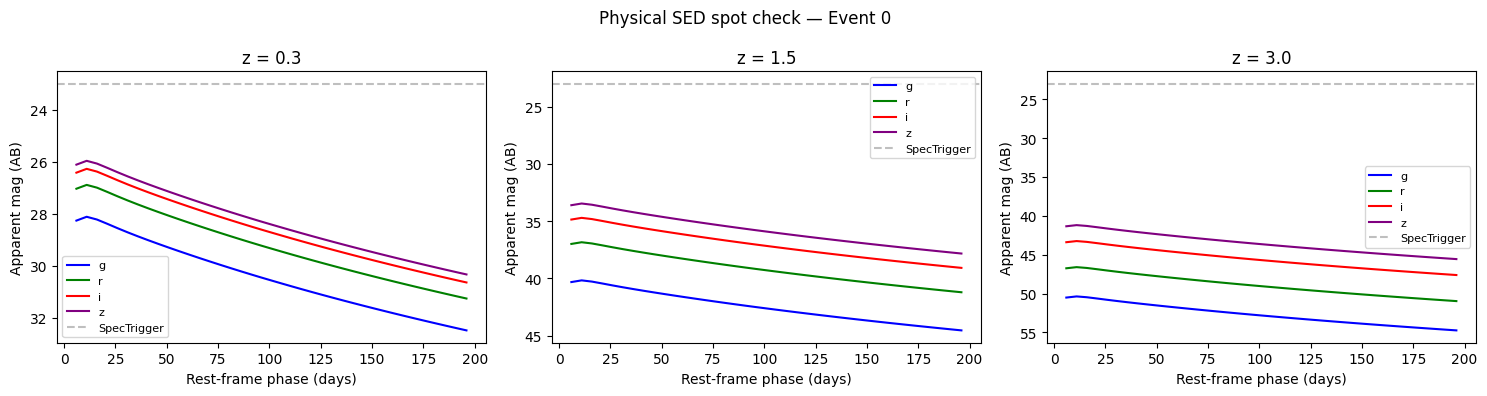

In [8]:
# SED spot check — physical track only
# Verify synthesize_mag_at_z() produces sensible magnitudes
# at representative redshifts before trusting metric results.
# GP templates do not use this code path.

from slsn_metrics.model import synthesize_mag_at_z

test_redshifts = [0.3, 1.5, 3.0]
test_phase     = 50.0   # mid-range post-peak phase
test_filters   = ['g', 'r', 'i', 'z']
n_events_check = 5

print('SED spot check — apparent mags from synthesize_mag_at_z()')
print(f'{"event":>6} {"z":>5} {"filt":>5} {"mag":>8}')
print('-' * 32)
for ev_idx in range(n_events_check):
    sed_entry = templates.sed_grid[ev_idx]
    for z_test in test_redshifts:
        for filt in test_filters:
            m = synthesize_mag_at_z(sed_entry, test_phase, z_test, filt)
            status = f'{m:.3f}' if np.isfinite(m) else 'NaN'
            print(f'{ev_idx:>6} {z_test:>5.1f} {filt:>5} {status:>8}')

# Light curve plot at three redshifts for event 0
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
phases_plot = np.arange(1, 200, 5).astype(float)
filt_colors = {'g': 'blue', 'r': 'green', 'i': 'red', 'z': 'purple'}
for ax, z_test in zip(axes, test_redshifts):
    sed_entry = templates.sed_grid[0]
    for filt, col in filt_colors.items():
        mags_plot = np.array([synthesize_mag_at_z(sed_entry, ph, z_test, filt)
                              for ph in phases_plot])
        finite = np.isfinite(mags_plot)
        if finite.sum() > 0:
            ax.plot(phases_plot[finite], mags_plot[finite], color=col, label=filt)
    ax.invert_yaxis()
    ax.set_xlabel('Rest-frame phase (days)')
    ax.set_ylabel('Apparent mag (AB)')
    ax.set_title(f'z = {z_test}')
    ax.axhline(23.0, ls='--', color='gray', alpha=0.5, label='SpecTrigger')
    ax.legend(fontsize=8)
plt.suptitle('Physical SED spot check — Event 0')
plt.tight_layout()
plt.savefig(get_output_dir('SLSNe', subdir='physical_figures') / 'sed_spot_check.png', dpi=150)
plt.show()


Saved: physical_eff_vs_z_naive_physical.png


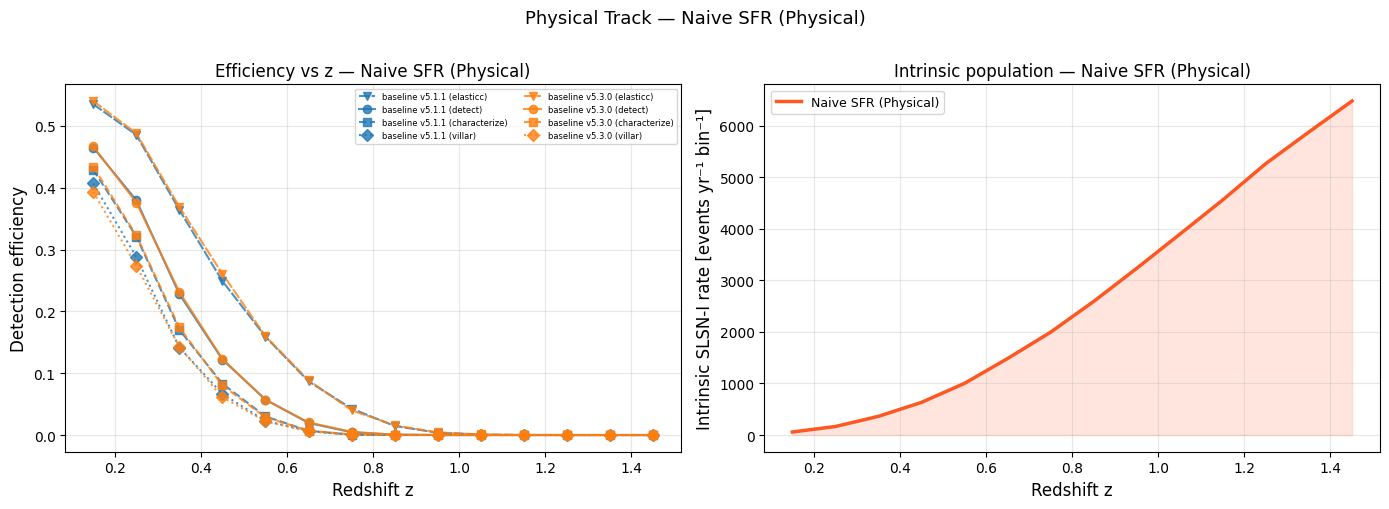

Saved: physical_eff_vs_z_o_dependent_physical.png


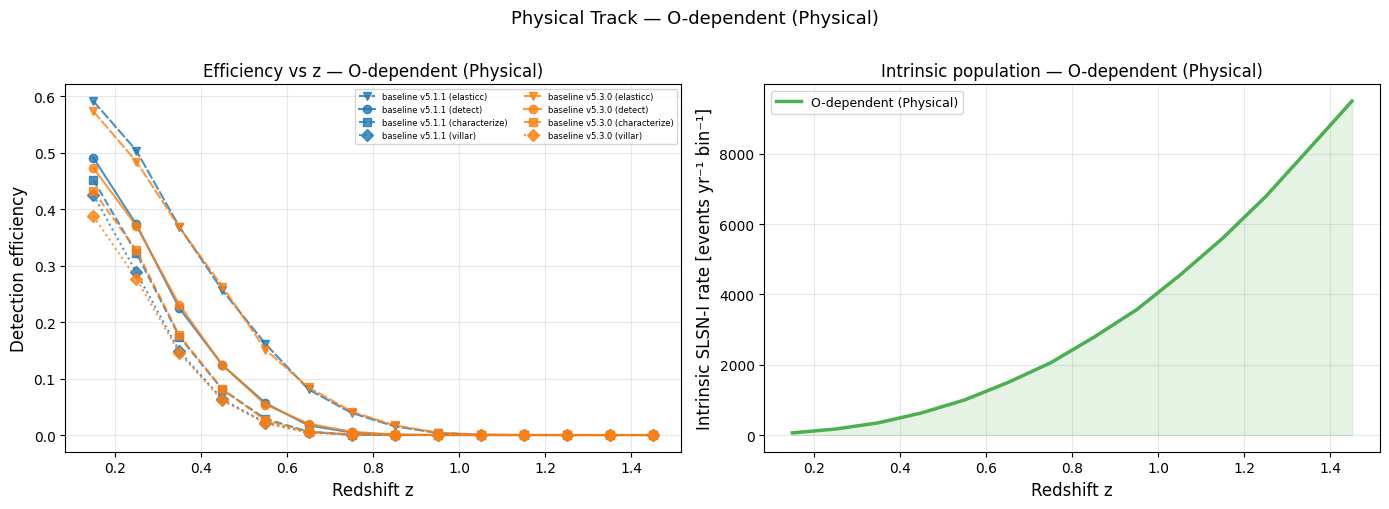

Saved: physical_eff_vs_z_fe_dependent_physical.png


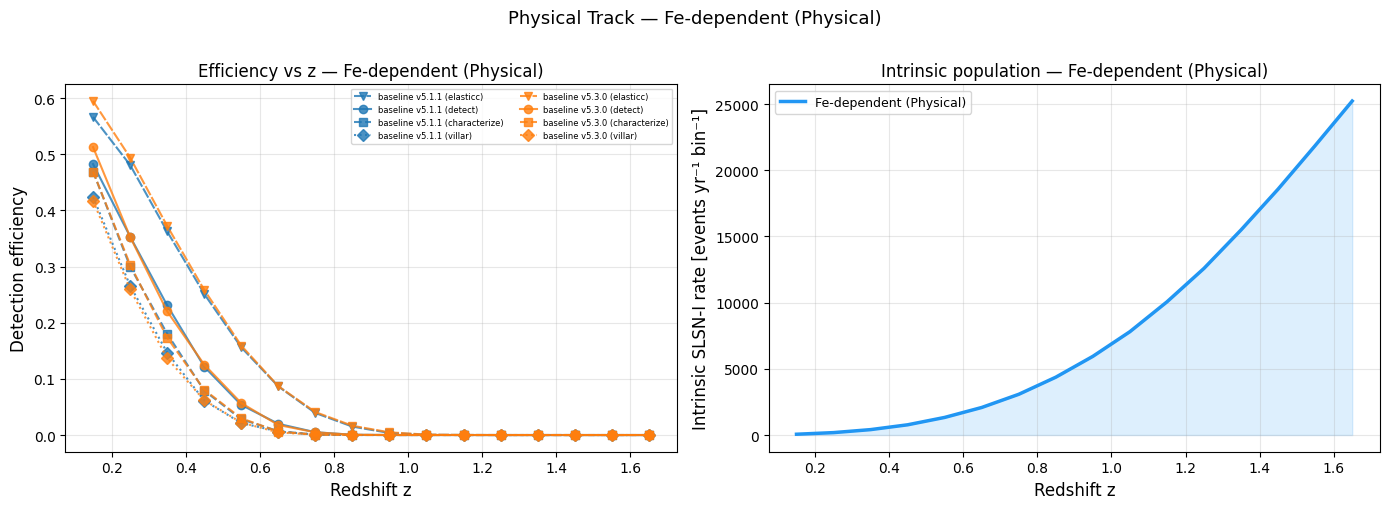

In [9]:
# ============================================================================
# CELL 7: Efficiency vs redshift — per model, all cadences, all metrics
# Left:  Detection efficiency per metric per cadence
# Right: Intrinsic population per model (one line, no metric breakdown)
# ============================================================================

model_labels = {
    'fe_dependent_physical': 'Fe-dependent (Physical)',
    'o_dependent_physical':  'O-dependent (Physical)',
    'naive_physical':        'Naive SFR (Physical)',
}
colors_model = {
    'naive_physical':        '#FF5722',
    'o_dependent_physical':  '#4CAF50',
    'fe_dependent_physical': '#2196F3',
}
colors_cadence = {
    'baseline_v5.1.1_10yrs':    '#1f77b4',
    'baseline_v5.3.0_10yrs':    '#ff7f0e',
    'noroll_v5.0.0_10yrs':      '#2ca02c',
    'poor_weather_v5.0.1_10yrs':'#d62728',
}
cadence_short = {
    'baseline_v5.1.1_10yrs':    'baseline v5.1.1',
    'baseline_v5.3.0_10yrs':    'baseline v5.3.0',
    'noroll_v5.0.0_10yrs':      'noroll',
    'poor_weather_v5.0.1_10yrs':'poor weather',
}
metric_keys_z = ['elasticc', 'detect', 'characterize', 'villar']
ls_metric = {
    'detect':       '-',
    'characterize': '--',
    'villar':       ':',
    'elasticc':     (0, (5, 1)),
}
markers_metric = {
    'detect':       'o',
    'characterize': 's',
    'villar':       'D',
    'elasticc':     'v',
}

for model in MODELS:
    if model not in pop_data:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    z_centers = pop_data[model]['z_centers']
    color     = colors_model[model]

    # Left panel — efficiency per metric per cadence
    # Left panel — efficiency per metric per cadence
    # Toggles — edit these to select which cadences and metrics appear
    PLOT_CADENCES_7 = ['baseline_v5.1.1_10yrs', 'baseline_v5.3.0_10yrs'] # or e.g. ['noroll_v5.0.0_10yrs']
    PLOT_METRICS_7  = metric_keys_z                     # or e.g. ['detect', 'elasticc']

    for cadence in PLOT_CADENCES_7:
        for metric in PLOT_METRICS_7:
            entry = pop_data[model][metric].get(cadence)
            if entry is None:
                continue
            eff_bins = entry['efficiency']
            label = f'{cadence_short[cadence]} ({metric})'
            axes[0].plot(z_centers, eff_bins,
                         marker=markers_metric[metric],
                         color=colors_cadence[cadence],
                         ls=ls_metric[metric], lw=1.5,
                         label=label, alpha=0.8)

    # Right panel — intrinsic population only (use ELAsTiCC n_events)
    # All cadences give same n_events per bin — just use first cadence
    ref_cadence = CADENCES[0]
    entry = pop_data[model]['elasticc'].get(ref_cadence)
    if entry is not None:
        n_ev_bins  = entry['n_events']
        count_bins = [n / SURVEY_YEARS for n in n_ev_bins]
        axes[1].plot(z_centers, count_bins,
                     color=color, lw=2.5,
                     label=model_labels[model])
        axes[1].fill_between(z_centers, 0, count_bins,
                             color=color, alpha=0.15)

    for ax in axes:
        ax.set_xlabel('Redshift z', fontsize=12)
        ax.grid(alpha=0.3)

    axes[0].set_ylabel('Detection efficiency', fontsize=12)
    axes[0].set_title(f'Efficiency vs z — {model_labels[model]}', fontsize=12)
    axes[0].legend(fontsize=6, ncol=2)

    axes[1].set_ylabel('Intrinsic SLSN-I rate [events yr⁻¹ bin⁻¹]', fontsize=12)
    axes[1].set_title(f'Intrinsic population — {model_labels[model]}', fontsize=12)
    axes[1].legend(fontsize=9)

    plt.suptitle(f'Physical Track — {model_labels[model]}', fontsize=13, y=1.01)
    plt.tight_layout()
    out_fig = get_output_dir('SLSNe') / f'physical_eff_vs_z_{model}.png'
    plt.savefig(out_fig, dpi=150, bbox_inches='tight')
    print(f'Saved: {out_fig.name}')
    plt.show()

Saved: n_success_per_year_detect_noroll_v5.0.0_10yrs.png


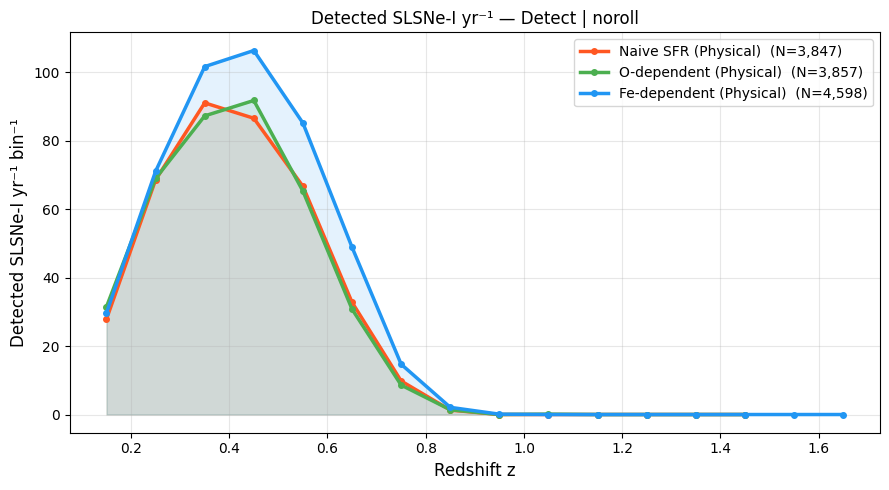

In [10]:
# ============================================================================
# CELL 7b: Detected SLSNe-I per year per z-bin — all 3 models, one metric
# ============================================================================
# Reload flags:
#   Templates  : NO
#   Population : NO
#   Mag grid   : NO
#   Kernel     : NO
#
# Toggles — change these to switch metric or cadence:
PLOT_METRIC  = 'detect'                # 'elasticc','detect','characterize','villar'
PLOT_CADENCE = 'noroll_v5.0.0_10yrs'  # any cadence in CADENCES

metric_label_7b = {
    'elasticc':     'ELAsTiCC',
    'detect':       'Detect',
    'characterize': 'Characterize',
    'villar':       'Villar',
}[PLOT_METRIC]

fig, ax = plt.subplots(figsize=(9, 5))

for model in MODELS:
    if model not in pop_data:
        continue
    entry = pop_data[model][PLOT_METRIC].get(PLOT_CADENCE)
    if entry is None:
        print(f'[skip] {model} / {PLOT_CADENCE} not in pop_data')
        continue

    z_centers   = pop_data[model]['z_centers']
    efficiency  = np.array(entry['efficiency'])
    n_events    = np.array(entry['n_events'])
    n_success   = efficiency * n_events
    n_per_year  = n_success / SURVEY_YEARS

    total = n_success.sum()
    label = f'{model_labels[model]}  (N={int(total):,})'

    ax.plot(z_centers, n_per_year,
            color=colors_model[model],
            lw=2.5, marker='o', ms=4,
            label=label)
    ax.fill_between(z_centers, 0, n_per_year,
                    color=colors_model[model], alpha=0.12)

ax.set_xlabel('Redshift z', fontsize=12)
ax.set_ylabel('Detected SLSNe-I yr⁻¹ bin⁻¹', fontsize=12)
ax.set_title(
    f'Detected SLSNe-I yr⁻¹ — {metric_label_7b} | '
    f'{cadence_short[PLOT_CADENCE]}',
    fontsize=12
)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()

out_fig = get_output_dir('SLSNe') / f'n_success_per_year_{PLOT_METRIC}_{PLOT_CADENCE}.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
print(f'Saved: {out_fig.name}')
plt.show()


naive_physical: 376,227 events at z=0.1-1.5

--- naive_physical x baseline_v5.1.1_10yrs ---
  detect: 3324 detected pixels / 36387 in-footprint pixels (9.1%)
  characterize: 2261 detected pixels / 36387 in-footprint pixels (6.2%)
  villar: 1935 detected pixels / 36387 in-footprint pixels (5.3%)


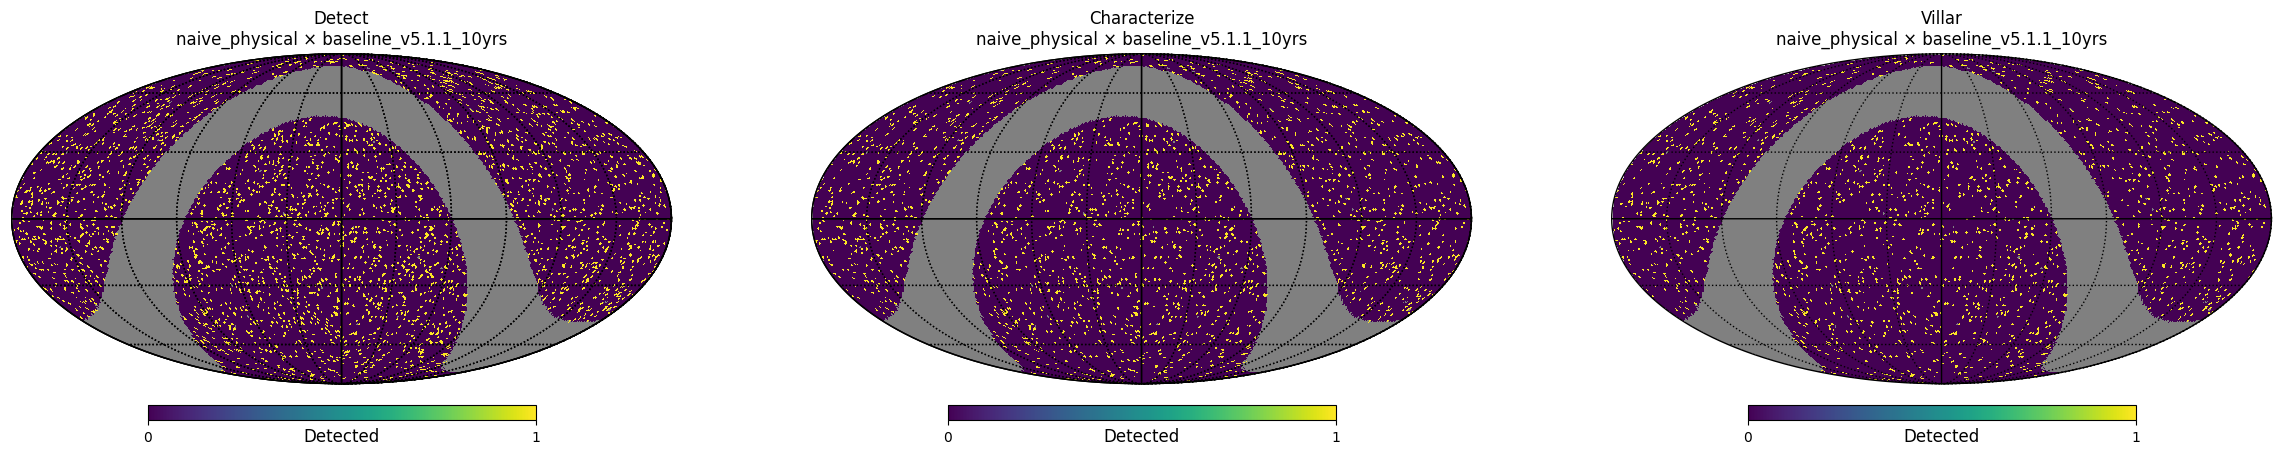

  Saved row: healpix_row_naive_physical_baseline_v5.1.1_10yrs_physical.png

--- naive_physical x baseline_v5.3.0_10yrs ---
  detect: 3341 detected pixels / 36388 in-footprint pixels (9.2%)
  characterize: 2259 detected pixels / 36388 in-footprint pixels (6.2%)
  villar: 1855 detected pixels / 36388 in-footprint pixels (5.1%)


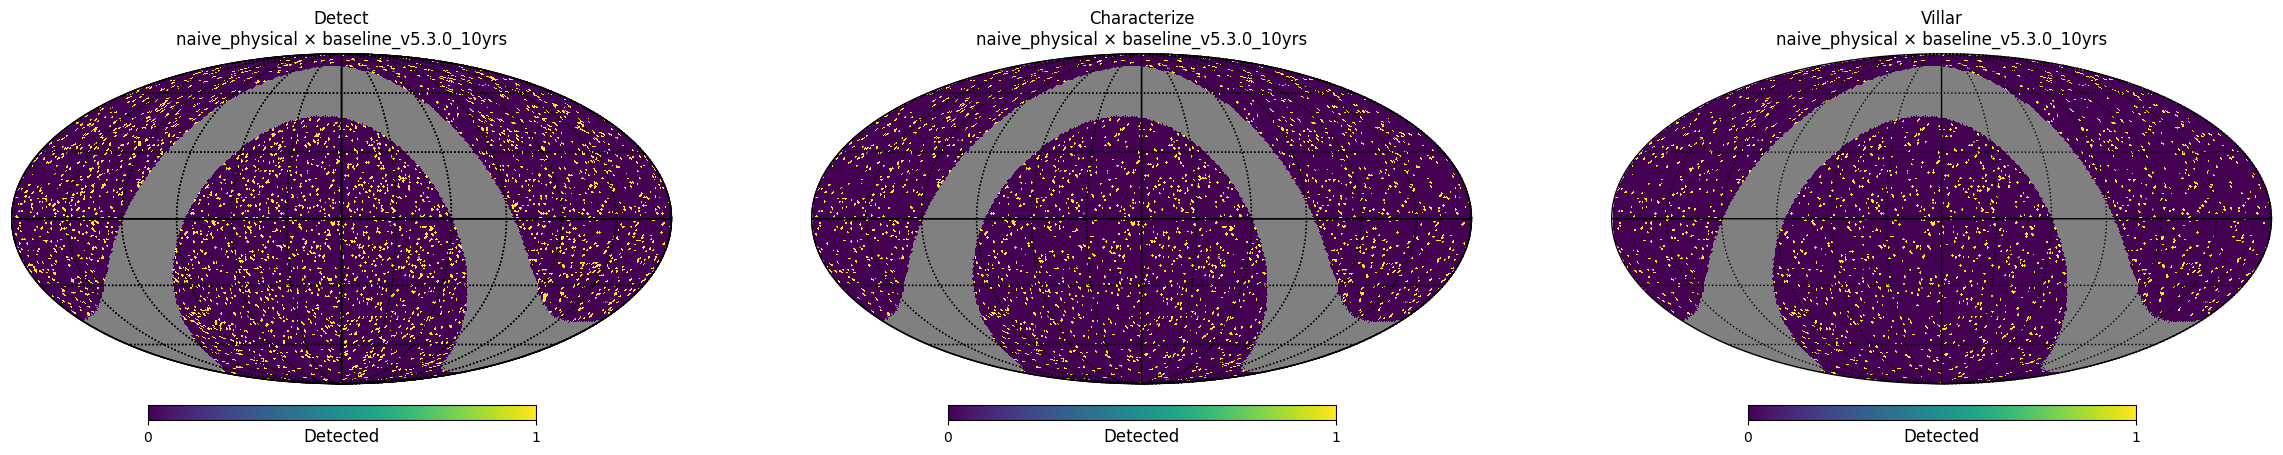

  Saved row: healpix_row_naive_physical_baseline_v5.3.0_10yrs_physical.png

o_dependent_physical: 466,780 events at z=0.1-1.5

--- o_dependent_physical x baseline_v5.1.1_10yrs ---
  detect: 3263 detected pixels / 36412 in-footprint pixels (9.0%)
  characterize: 2237 detected pixels / 36412 in-footprint pixels (6.1%)
  villar: 1913 detected pixels / 36412 in-footprint pixels (5.3%)


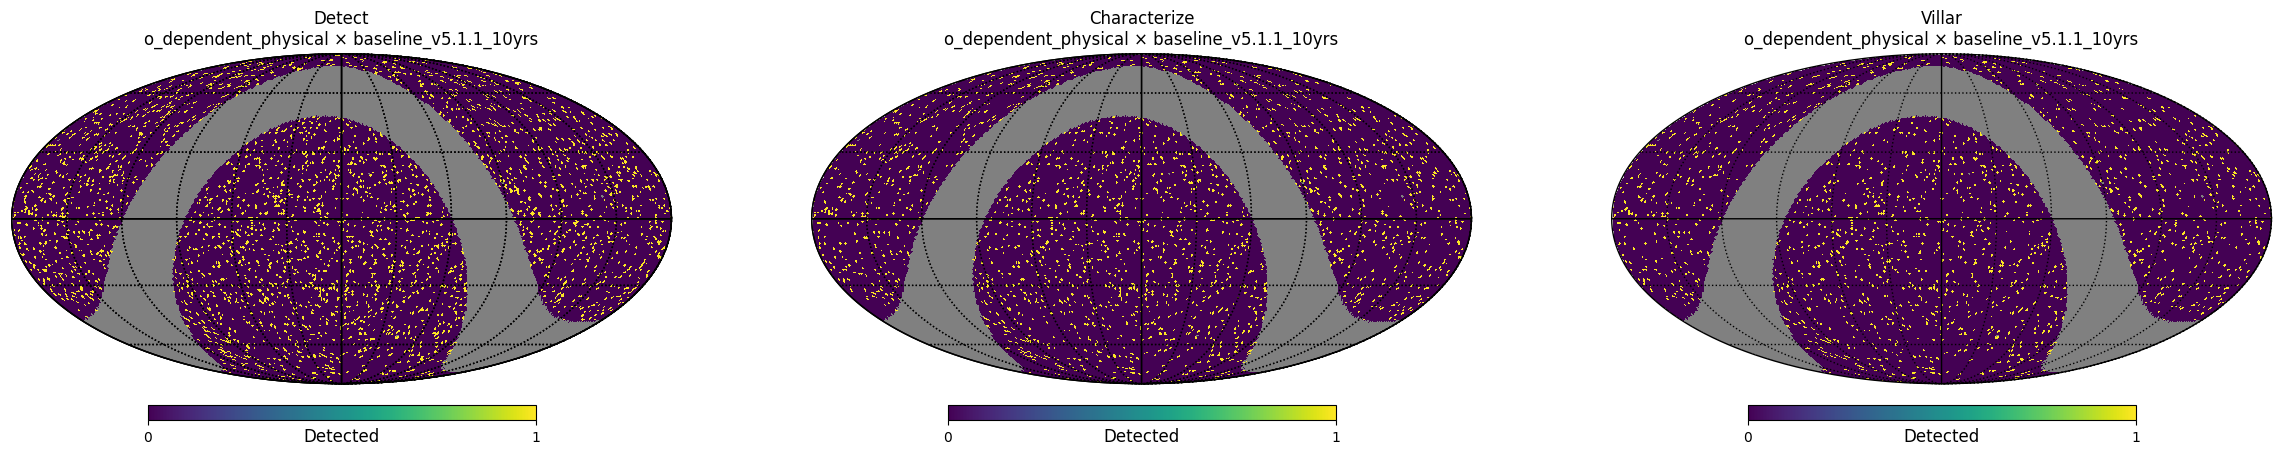

  Saved row: healpix_row_o_dependent_physical_baseline_v5.1.1_10yrs_physical.png

--- o_dependent_physical x baseline_v5.3.0_10yrs ---
  detect: 3313 detected pixels / 36412 in-footprint pixels (9.1%)
  characterize: 2244 detected pixels / 36412 in-footprint pixels (6.2%)
  villar: 1830 detected pixels / 36412 in-footprint pixels (5.0%)


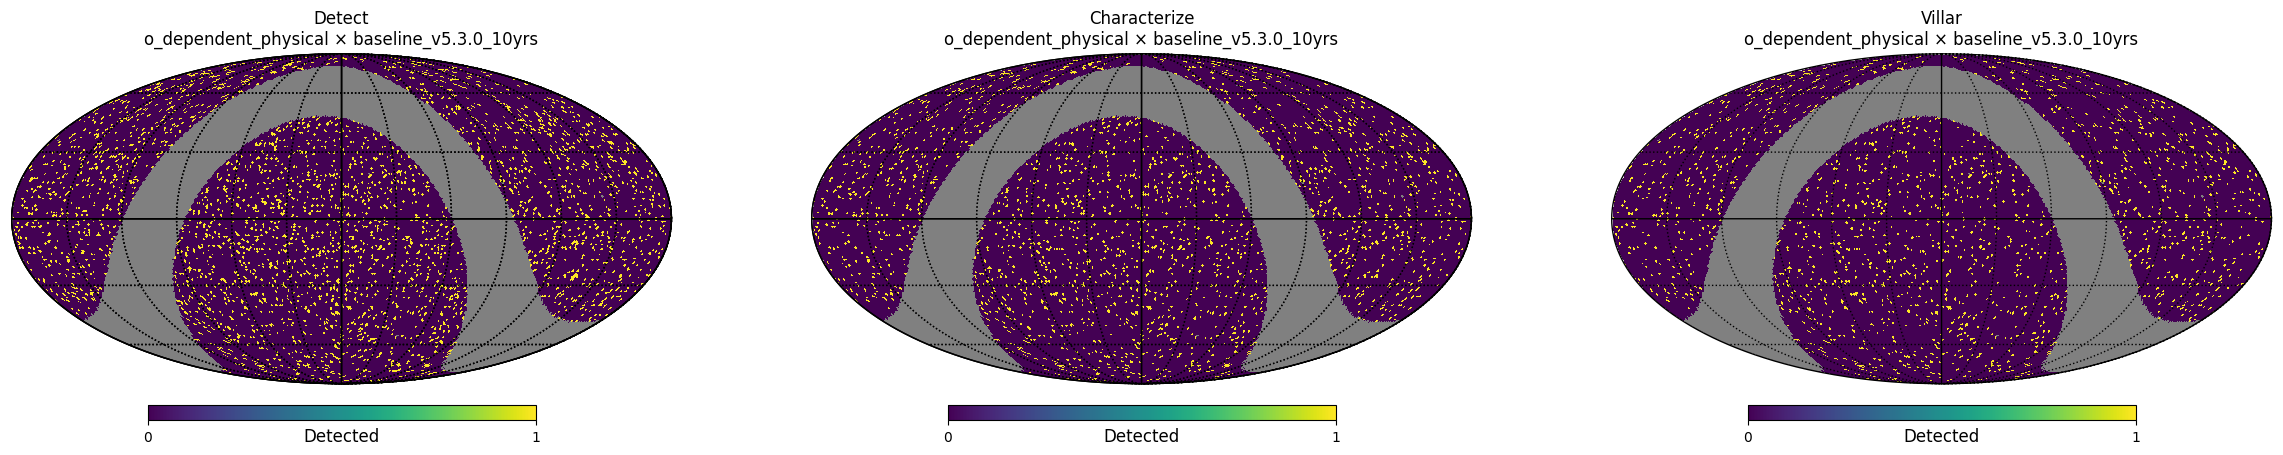

  Saved row: healpix_row_o_dependent_physical_baseline_v5.3.0_10yrs_physical.png

fe_dependent_physical: 1,298,359 events at z=0.1-1.7

--- fe_dependent_physical x baseline_v5.1.1_10yrs ---
  detect: 3893 detected pixels / 36418 in-footprint pixels (10.7%)
  characterize: 2611 detected pixels / 36418 in-footprint pixels (7.2%)
  villar: 2187 detected pixels / 36418 in-footprint pixels (6.0%)


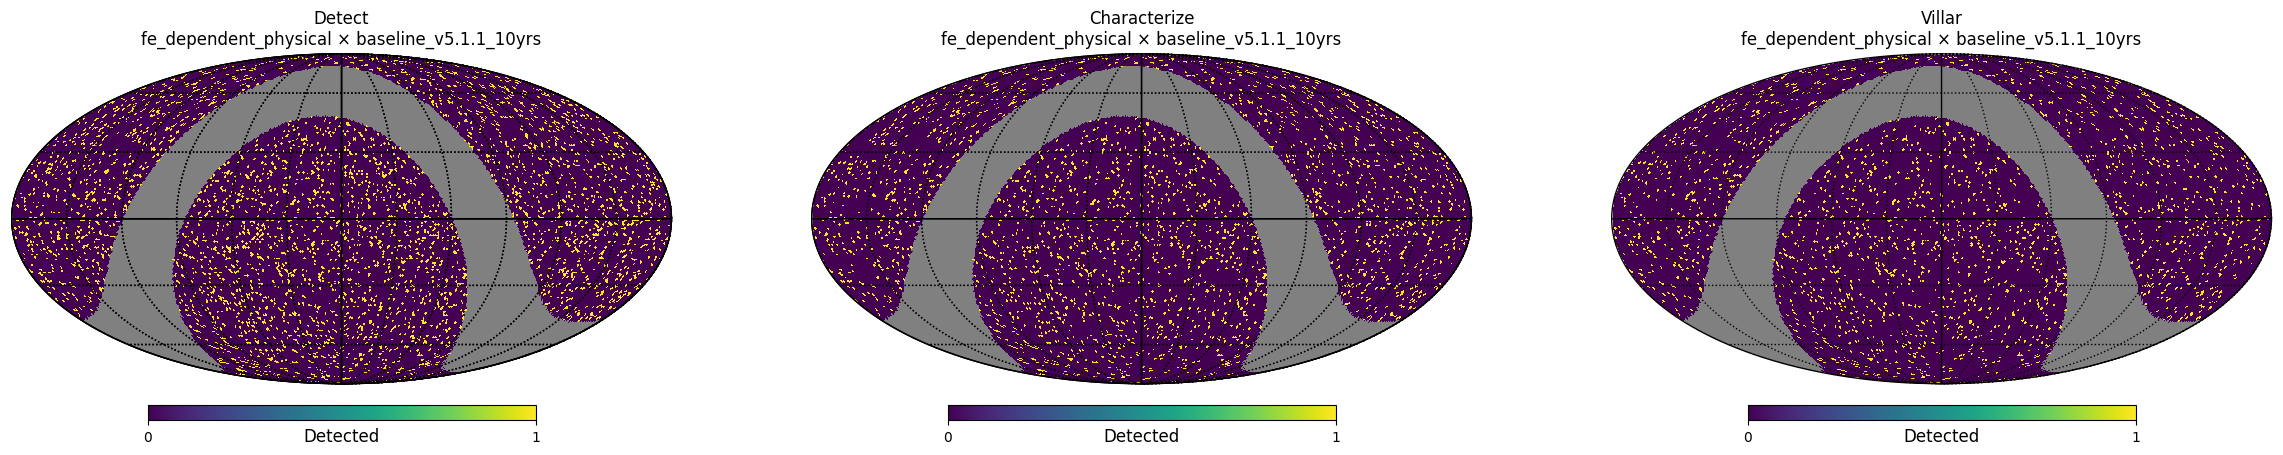

  Saved row: healpix_row_fe_dependent_physical_baseline_v5.1.1_10yrs_physical.png

--- fe_dependent_physical x baseline_v5.3.0_10yrs ---
  detect: 3912 detected pixels / 36418 in-footprint pixels (10.7%)
  characterize: 2632 detected pixels / 36418 in-footprint pixels (7.2%)
  villar: 2120 detected pixels / 36418 in-footprint pixels (5.8%)


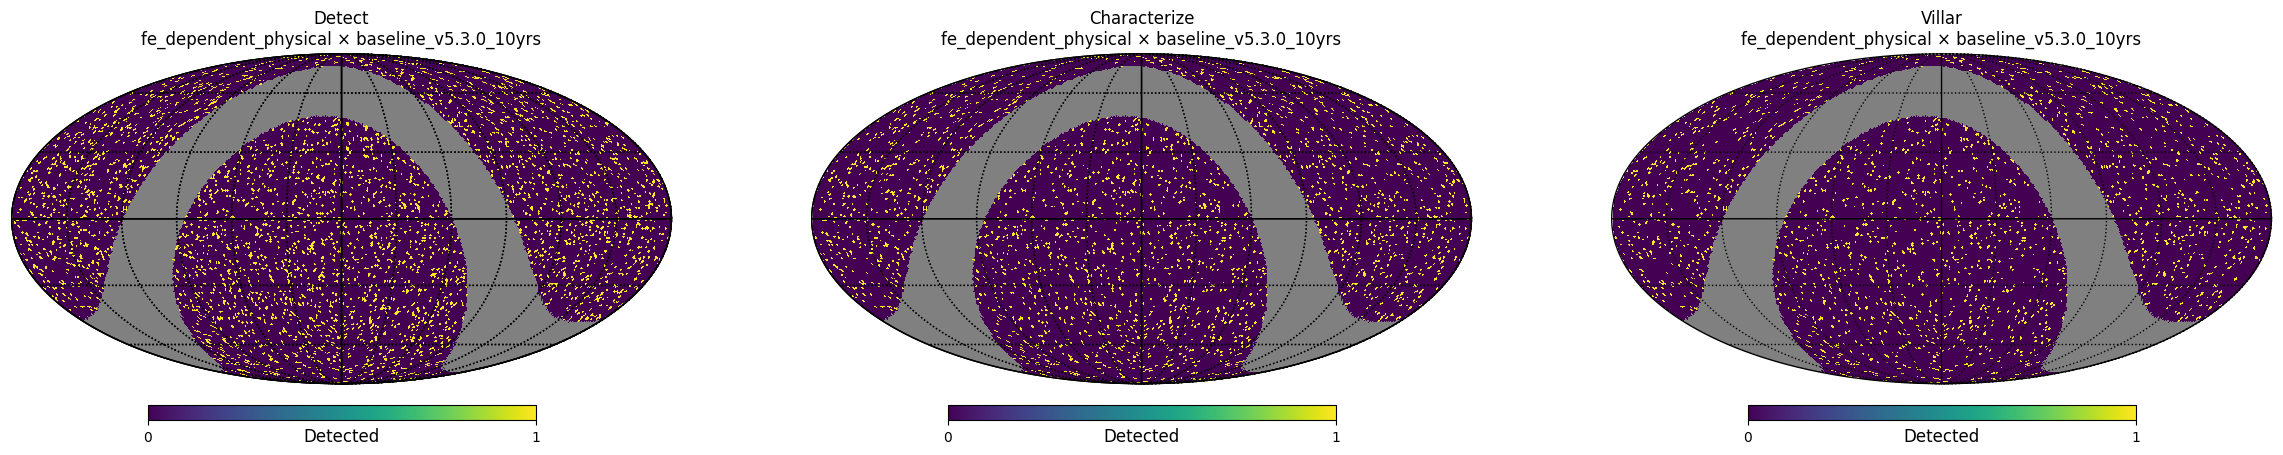

  Saved row: healpix_row_fe_dependent_physical_baseline_v5.3.0_10yrs_physical.png


In [11]:
# ============================================================================
# CELL 9: HEALPix sky maps — all 3 models × all 4 cadences
# Shows detection efficiency per pixel within Rubin observed footprint.
# Grey   = outside injected population (galactic plane + truly empty pixels)
# Purple = injected AND in-footprint (evaluated by MAF), not detected
# Yellow = detected (MAF enforces Rubin footprint)
#
# NOTE: -1 sentinel (out-of-footprint) events are excluded from both
# the purple background and detection count. This makes the Rubin
# footprint boundary visible naturally without an explicit mask.
# ============================================================================
reload(diag_mod)
import healpy as hp

METRIC_KEYS     = ['detect', 'characterize', 'villar']
HEALPIX_FIGSIZE = (24, 4)
NSIDE           = 64
# Toggle — only show cadences with clean badval-fixed npy files
PLOT_CADENCES_9 = ['baseline_v5.1.1_10yrs', 'baseline_v5.3.0_10yrs']

for model in MODELS:
    sp    = pop_slicers[model].slice_points
    z_all = np.asarray(sp['z'])

    # Find z_max that matches adaptive .npy size
    z_max_used = None
    for z_max_try in [1.7, 1.5]:
        test_npy = get_output_dir('SLSNe', subdir=model) / \
           f'metric_values_elasticc_{model}_{CADENCES[0]}_z0.1-{z_max_try}_adaptive.npy'
        if test_npy.exists():
            test_arr = np.load(str(test_npy))
            mask_try = (z_all >= 0.1) & (z_all <= z_max_try)
            if len(test_arr) == mask_try.sum():
                z_max_used = z_max_try
                mask_z     = mask_try
                break
    if z_max_used is None:
        print(f'{model}: no matching adaptive .npy — skipping')
        continue

    ra_map  = np.asarray(sp['ra'])[mask_z]
    dec_map = np.asarray(sp['dec'])[mask_z]
    print(f'\n{model}: {mask_z.sum():,} events at z=0.1-{z_max_used}')

    # Precompute pixel indices once per model
    npix  = hp.nside2npix(NSIDE)
    theta = 0.5 * np.pi - dec_map
    pix   = hp.ang2pix(NSIDE, theta, ra_map)

    for cadence in PLOT_CADENCES_9:
        print(f'\n--- {model} x {cadence} ---')

        fig = plt.figure(figsize=HEALPIX_FIGSIZE)

        for col_idx, metric in enumerate(METRIC_KEYS):
            npy_path = get_output_dir('SLSNe', subdir=model) / \
                       f'metric_values_{metric}_{model}_{cadence}_z0.1-{z_max_used}_adaptive.npy'
            if not npy_path.exists():
                print(f'  Skipping {metric} — {npy_path.name} not found')
                continue

            metric_map = np.load(str(npy_path))
            if len(metric_map) != len(ra_map):
                print(f'  Size mismatch: npy={len(metric_map)}, '
                      f'pop={len(ra_map)} — skipping {metric}')
                continue

            # Build detection and footprint maps
            # -1 = out-of-footprint (badval), 0 = not detected, 1 = detected
            injected_fp  = np.zeros(npix)  # in-footprint injected events
            detected_map = np.zeros(npix)  # detected events

            for i, p in enumerate(pix):
                if metric_map[i] == -1:
                    continue                      # skip out-of-footprint
                injected_fp[p] += 1              # evaluated by MAF
                if metric_map[i] == 1:
                    detected_map[p] += 1         # detected

            # Efficiency map
            # Grey   = no injected events (galactic plane, empty pixels)
            # Purple = in-footprint, not detected
            # Yellow = detected
            eff_map = np.full(npix, hp.UNSEEN)
            eff_map[injected_fp > 0]  = 0.0     # purple
            eff_map[detected_map > 0] = 1.0     # yellow

            n_det_pix = int((detected_map > 0).sum())
            n_fp_pix  = int((injected_fp > 0).sum())
            print(f'  {metric}: {n_det_pix} detected pixels / '
                  f'{n_fp_pix} in-footprint pixels '
                  f'({100*n_det_pix/max(n_fp_pix,1):.1f}%)')

            hp.mollview(
                eff_map,
                title  = f'{metric.capitalize()}\n{model} × {cadence}',
                unit   = 'Detected',
                cmap   = 'viridis',
                min    = 0,
                max    = 1,
                hold   = False,
                sub    = (1, len(METRIC_KEYS), col_idx + 1),
                fig    = fig.number
            )
            hp.graticule()

        out_row = get_output_dir('SLSNe', subdir=model) / \
                  f'healpix_row_{model}_{cadence}_physical.png'
        plt.savefig(str(out_row), dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f'  Saved row: {out_row.name}')

naive: 376,227 events, z=0.1-1.5


o_dependent: 466,780 events, z=0.1-1.5
fe_dependent: 1,298,359 events, z=0.1-1.7

=== baseline_v5.1.1_10yrs | detect ===


/users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/py_files/slsn_metrics/diagnostics.py:2658: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved: mc_panel_3panel_detect_baseline_v5.1.1_10yrs.png


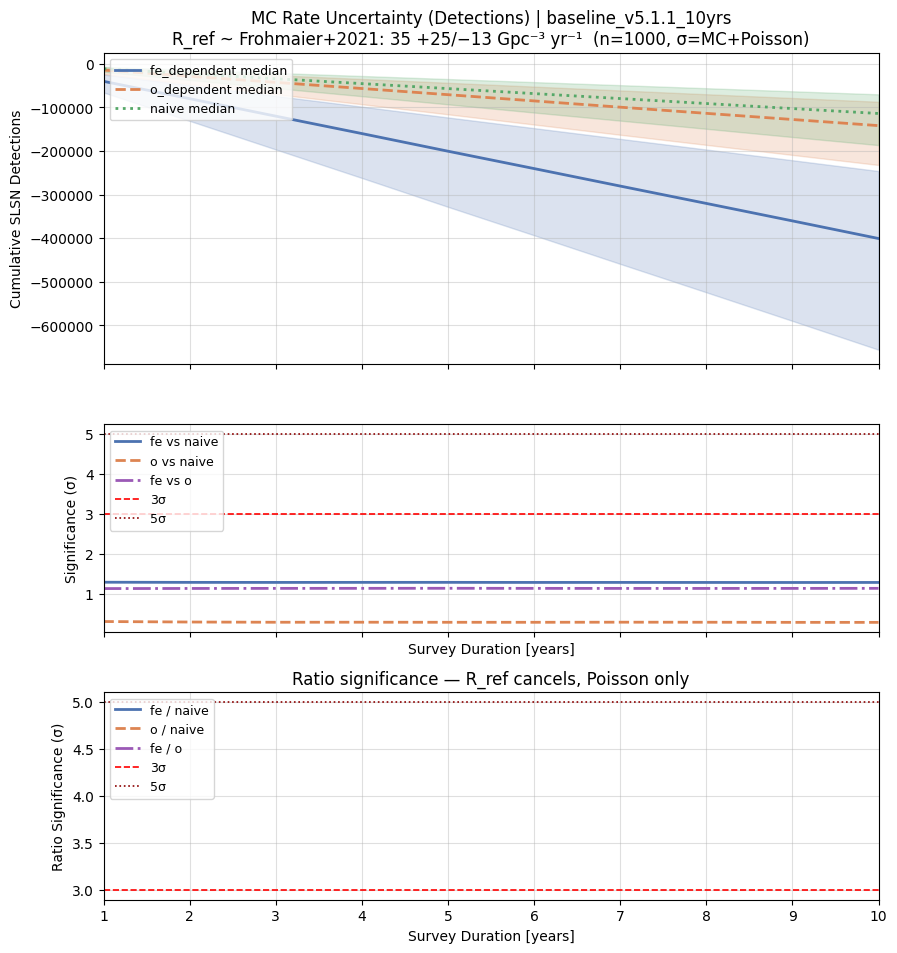


=== baseline_v5.3.0_10yrs | detect ===
  Saved: mc_panel_3panel_detect_baseline_v5.3.0_10yrs.png


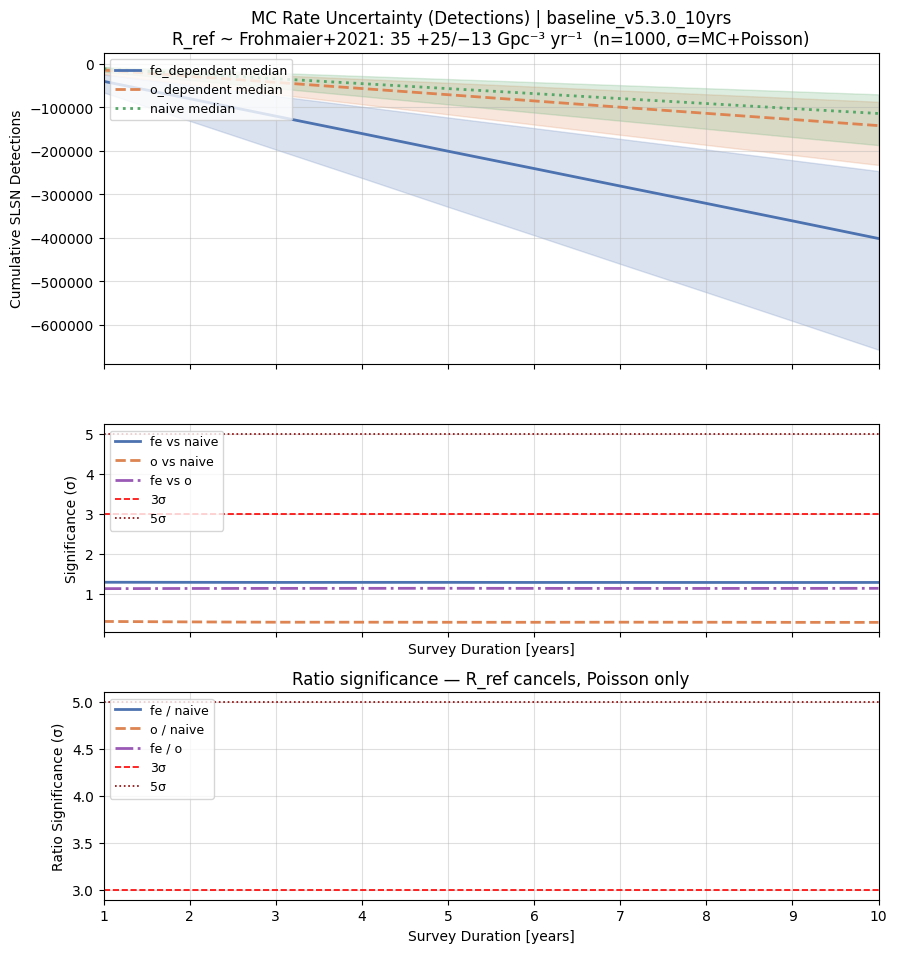


=== noroll_v5.0.0_10yrs | detect ===
  Saved: mc_panel_3panel_detect_noroll_v5.0.0_10yrs.png


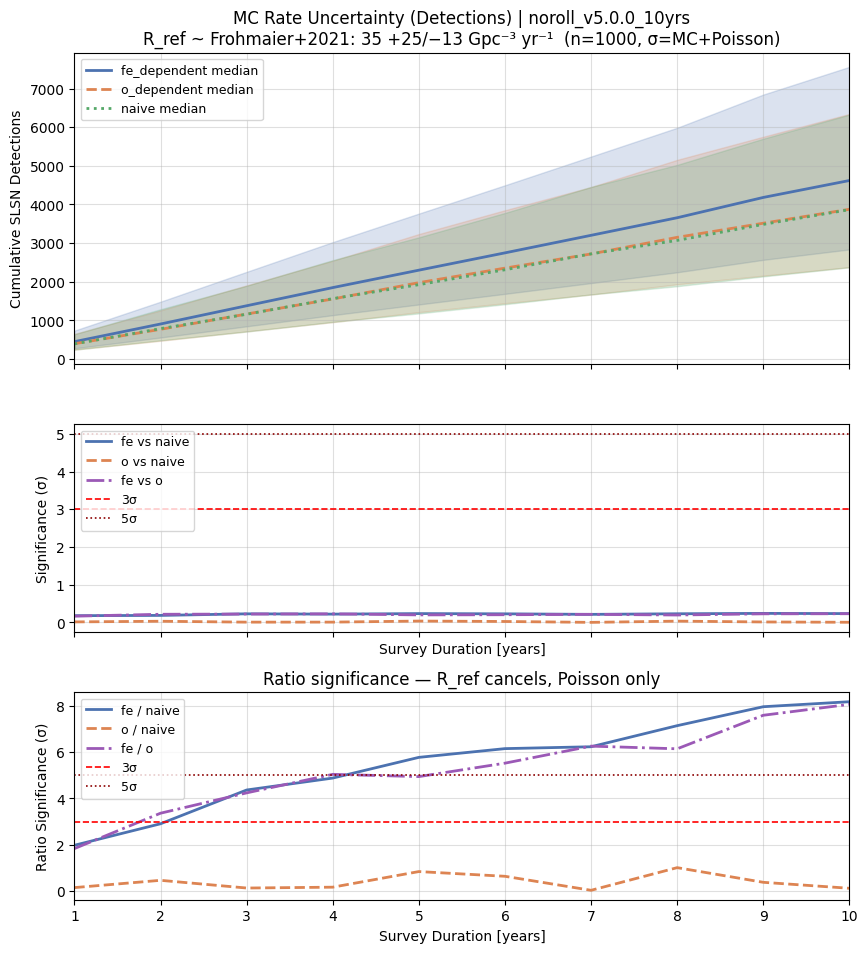


=== poor_weather_v5.0.1_10yrs | detect ===
  Saved: mc_panel_3panel_detect_poor_weather_v5.0.1_10yrs.png


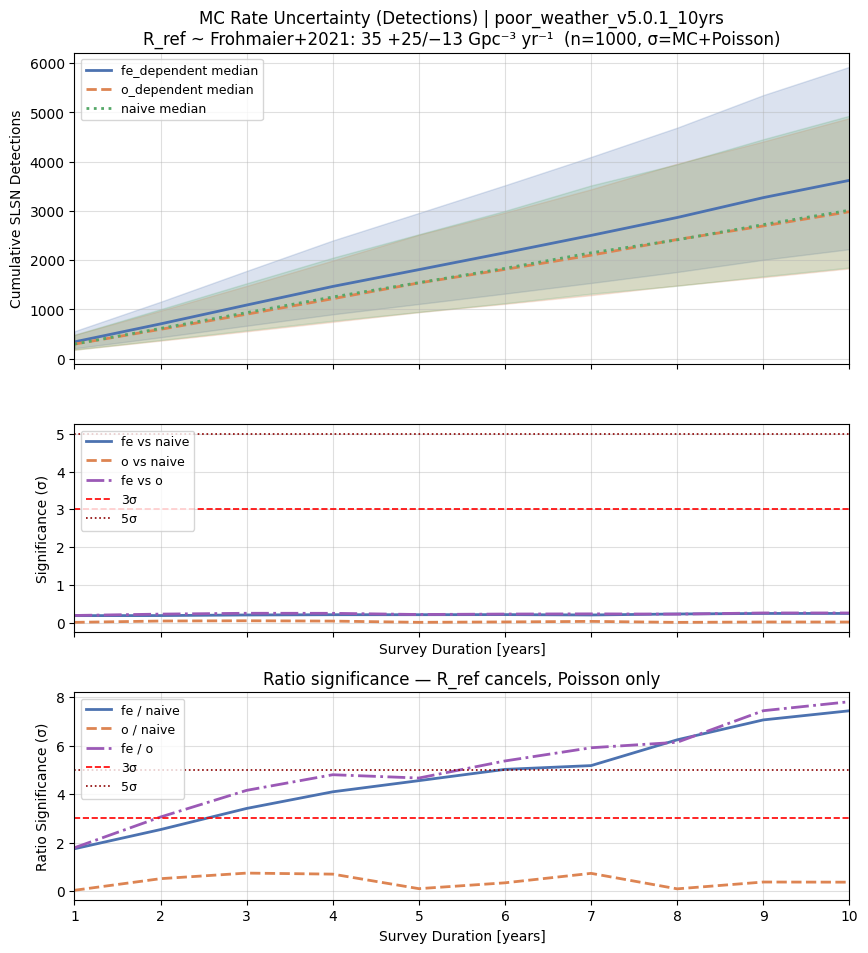

In [12]:
# ============================================================================
# CELL 10 - MC: Monte Carlo rate uncertainty — all cadences, all models
# ============================================================================
import slsn_metrics.diagnostics as diag_mod
from importlib import reload
reload(diag_mod)
from slsn_metrics.diagnostics import plot_mc_rate_uncertainty_panel

METRIC_KEY   = 'detect'
METRIC_LABEL = {
    'detect':       'Detections',
    'characterize': 'Characterized',
    'villar':       'Villar Detections',
    'elasticc':     'ELAsTiCC Detections',
}[METRIC_KEY]

MODEL_SHORT = {
    'naive_physical':        'naive',
    'o_dependent_physical':  'o_dependent',
    'fe_dependent_physical': 'fe_dependent',
}

pop_data_mc = {}
for model in MODELS:
    short = MODEL_SHORT[model]
    sp    = pop_slicers[model].slice_points
    z_all = np.asarray(sp['z'])

    # Find z_max that matches adaptive .npy size
    z_max_used = None
    for z_max_try in [1.7, 1.5]:
        test_npy = get_output_dir('SLSNe', subdir=model) / \
                   f'metric_values_elasticc_{model}_{CADENCES[0]}_z0.1-{z_max_try}_adaptive.npy'
        if test_npy.exists():
            test_arr = np.load(str(test_npy))
            mask_try = (z_all >= 0.1) & (z_all <= z_max_try)
            if len(test_arr) == mask_try.sum():
                z_max_used = z_max_try
                mask_z     = mask_try
                break
    if z_max_used is None:
        print(f'{model}: no matching adaptive .npy — skipping')
        continue

    peak_times = np.asarray(sp['peak_time'])[mask_z]
    z_vals     = z_all[mask_z]

    # Load per-cadence .npy arrays for this metric
    metric_arrays = {}
    for cadence in CADENCES:
        npy_path = get_output_dir('SLSNe', subdir=model) / \
                   f'metric_values_{METRIC_KEY}_{model}_{cadence}_z0.1-{z_max_used}_adaptive.npy'
        if npy_path.exists():
            arr = np.load(str(npy_path)).astype(int)
            if len(arr) == len(peak_times):
                metric_arrays[cadence] = arr
            else:
                print(f'  Size mismatch {model} {cadence}: '
                      f'npy={len(arr):,} vs peak_times={len(peak_times):,}')
                metric_arrays[cadence] = None
        else:
            print(f'  Missing: {npy_path.name}')
            metric_arrays[cadence] = None

    pop_data_mc[short] = {
        METRIC_KEY:   metric_arrays,
        'peak_time':  peak_times,
        'z':          z_vals,
    }
    print(f'{short}: {len(peak_times):,} events, z=0.1-{z_max_used}')

# Run MC panel for each cadence
SAVE_DIR = get_output_dir('SLSNe')
for cadence in CADENCES:
    print(f'\n=== {cadence} | {METRIC_KEY} ===')
    plot_mc_rate_uncertainty_panel(
        pop_data       = pop_data_mc,
        cadence        = cadence,
        metric_key     = METRIC_KEY,
        metric_label   = METRIC_LABEL,
        R_ref_nominal  = 35.0,
        n_realizations = 1000,
        seed           = 42,
        save_dir       = SAVE_DIR,
    )


MODEL: Naive SFR (Physical)

  Cadence: Baseline v5.3.0
         z-bin   n_events        ELAsTiCC          Detect    Characterize          Villar
  ---------------------------------------------------------------------------------------
  [0.1,0.2)         585    316 ( 54.0%)    273 ( 46.7%)    254 ( 43.4%)    230 ( 39.3%)
  [0.2,0.3)       1,654    807 ( 48.8%)    622 ( 37.6%)    534 ( 32.3%)    453 ( 27.4%)
  [0.3,0.4)       3,626   1338 ( 36.9%)    839 ( 23.1%)    631 ( 17.4%)    517 ( 14.3%)
  [0.4,0.5)       6,335   1651 ( 26.1%)    780 ( 12.3%)    508 (  8.0%)    387 (  6.1%)
  [0.5,0.6)      10,027   1602 ( 16.0%)    570 (  5.7%)    287 (  2.9%)    223 (  2.2%)
  [0.6,0.7)      14,847   1315 (  8.9%)    304 (  2.0%)    106 (  0.7%)     86 (  0.6%)
  [0.7,0.8)      19,960    800 (  4.0%)    102 (  0.5%)     19 (  0.1%)     14 (  0.1%)
  [0.8,0.9)      25,926    403 (  1.6%)     14 (  0.1%)      2 (  0.0%)      1 (  0.0%)
  [0.9,1.0)      32,355    141 (  0.4%)      2 (  0.0%)    

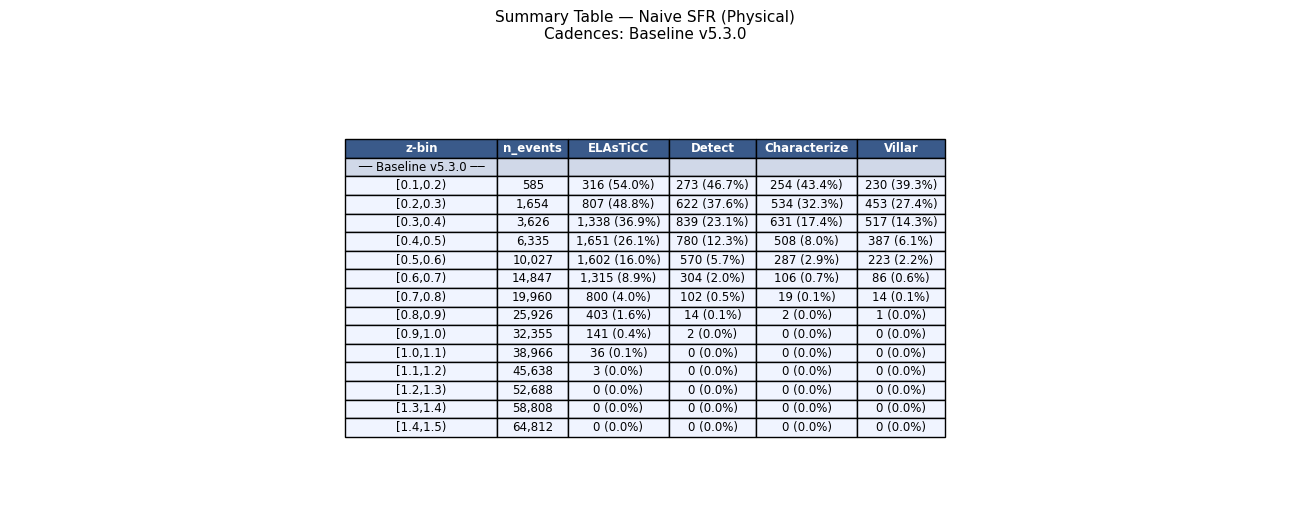


MODEL: O-dependent (Physical)

  Cadence: Baseline v5.3.0
         z-bin   n_events        ELAsTiCC          Detect    Characterize          Villar
  ---------------------------------------------------------------------------------------
  [0.1,0.2)         609    349 ( 57.3%)    288 ( 47.3%)    263 ( 43.2%)    236 ( 38.8%)
  [0.2,0.3)       1,698    822 ( 48.4%)    629 ( 37.0%)    556 ( 32.7%)    470 ( 27.7%)
  [0.3,0.4)       3,479   1279 ( 36.8%)    801 ( 23.0%)    613 ( 17.6%)    505 ( 14.5%)
  [0.4,0.5)       6,286   1652 ( 26.3%)    777 ( 12.4%)    509 (  8.1%)    386 (  6.1%)
  [0.5,0.6)       9,975   1508 ( 15.1%)    536 (  5.4%)    263 (  2.6%)    205 (  2.1%)
  [0.6,0.7)      14,904   1256 (  8.4%)    302 (  2.0%)     86 (  0.6%)     67 (  0.4%)
  [0.7,0.8)      20,556    855 (  4.2%)    118 (  0.6%)     27 (  0.1%)     17 (  0.1%)
  [0.8,0.9)      27,787    472 (  1.7%)     14 (  0.1%)      1 (  0.0%)      0 (  0.0%)
  [0.9,1.0)      35,681    152 (  0.4%)      0 (  0.0%)  

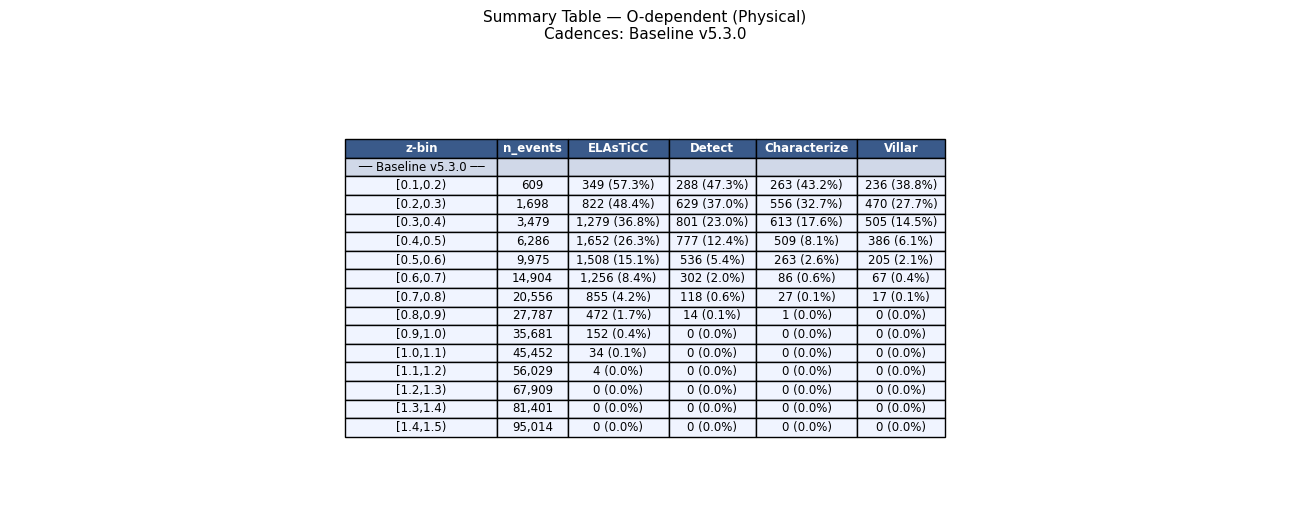


MODEL: Fe-dependent (Physical)

  Cadence: Baseline v5.3.0
         z-bin   n_events        ELAsTiCC          Detect    Characterize          Villar
  ---------------------------------------------------------------------------------------
  [0.1,0.2)         597    355 ( 59.5%)    306 ( 51.3%)    280 ( 46.9%)    249 ( 41.7%)
  [0.2,0.3)       1,820    899 ( 49.4%)    642 ( 35.3%)    552 ( 30.3%)    472 ( 25.9%)
  [0.3,0.4)       4,083   1520 ( 37.2%)    899 ( 22.0%)    708 ( 17.3%)    558 ( 13.7%)
  [0.4,0.5)       7,727   1997 ( 25.8%)    969 ( 12.5%)    623 (  8.1%)    479 (  6.2%)
  [0.5,0.6)      13,294   2116 ( 15.9%)    756 (  5.7%)    397 (  3.0%)    295 (  2.2%)
  [0.6,0.7)      20,808   1810 (  8.7%)    372 (  1.8%)    127 (  0.6%)     96 (  0.5%)
  [0.7,0.8)      30,768   1257 (  4.1%)    148 (  0.5%)     22 (  0.1%)     21 (  0.1%)
  [0.8,0.9)      43,696    721 (  1.7%)     23 (  0.1%)      3 (  0.0%)      3 (  0.0%)
  [0.9,1.0)      59,441    285 (  0.5%)      2 (  0.0%) 

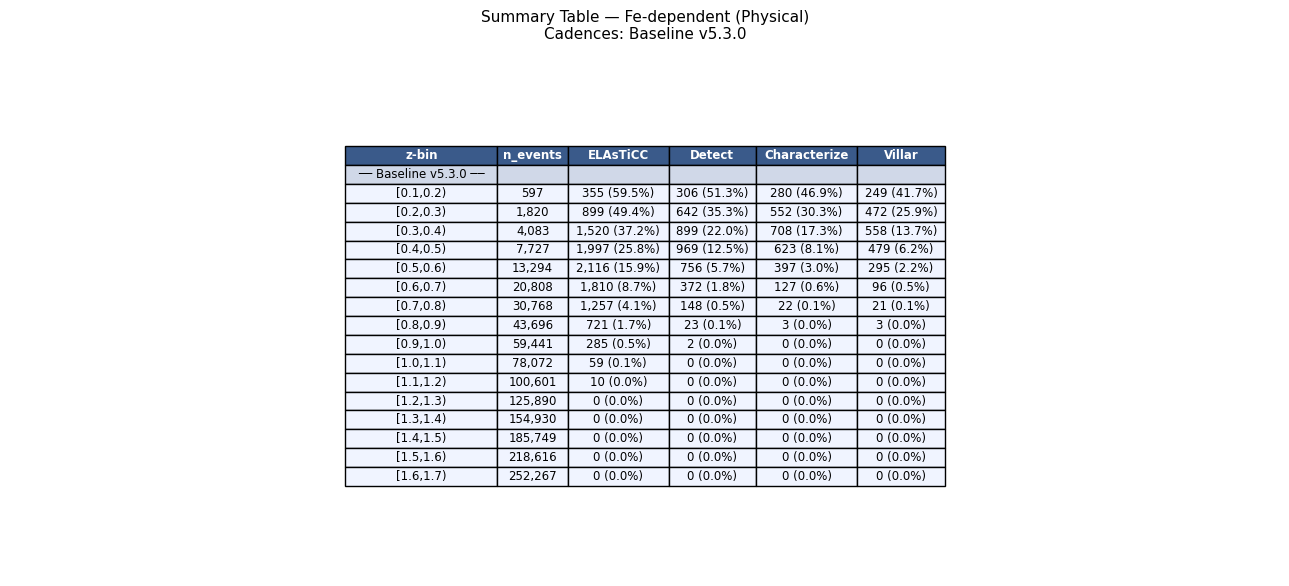

In [13]:
# ============================================================================
# CELL 11: Summary tables — one per model, cadences as row groups
# Rows = z-bins, Columns = metrics
# Shows n_success (efficiency%)
# Saves one PNG per model
# ============================================================================

# Toggles
PLOT_CADENCES_11 = ['baseline_v5.3.0_10yrs']  # or e.g. ['baseline_v5.3.0_10yrs']

METRIC_DISPLAY = {
    'SLSN_ELAsTiCC_Metric':              'ELAsTiCC',
    'SLSN_Detect_Physical_Metric':       'Detect',
    'SLSN_Characterize_Physical_Metric': 'Characterize',
    'SLSN_Villar_Physical_Metric':       'Villar',
}
METRIC_ORDER = list(METRIC_DISPLAY.keys())
CADENCE_LABELS = {
    'baseline_v5.1.1_10yrs':    'Baseline v5.1.1',
    'baseline_v5.3.0_10yrs':    'Baseline v5.3.0',
    'noroll_v5.0.0_10yrs':      'No Roll',
    'poor_weather_v5.0.1_10yrs':'Poor Weather',
}

for model in MODELS:
    df = ADAPTIVE[model].copy()
    z_bins = sorted(df[['z_lo','z_hi']].drop_duplicates().values.tolist())

    # ----------------------------------------------------------------
    # 1. Print to terminal (unchanged)
    # ----------------------------------------------------------------
    print(f"\n{'='*90}")
    print(f"MODEL: {model_labels[model]}")
    print(f"{'='*90}")

    for cadence in PLOT_CADENCES_11:
        print(f"\n  Cadence: {CADENCE_LABELS.get(cadence, cadence)}")
        header = f"  {'z-bin':>12} {'n_events':>10}"
        for m in METRIC_ORDER:
            header += f"  {METRIC_DISPLAY[m]:>14}"
        print(header)
        print("  " + "-" * (len(header) - 2))

        for z_lo, z_hi in z_bins:
            row_data = df[
                (df['z_lo'] == z_lo) &
                (df['z_hi'] == z_hi) &
                (df['cadence'] == cadence)
            ]
            if row_data.empty:
                continue
            n_ev = int(row_data['n_events'].iloc[0])
            row_str = f"  [{z_lo:.1f},{z_hi:.1f})  {n_ev:>10,}"
            for m in METRIC_ORDER:
                mrow = row_data[row_data['metric'] == m]
                if mrow.empty:
                    row_str += f"  {'—':>14}"
                else:
                    n_suc = int(mrow['n_success'].iloc[0])
                    eff   = float(mrow['efficiency'].iloc[0]) * 100
                    row_str += f"  {n_suc:>5} ({eff:>5.1f}%)"
            print(row_str)

    # ----------------------------------------------------------------
    # 2. Build table data for matplotlib
    # ----------------------------------------------------------------
    col_headers = ['z-bin', 'n_events'] + [METRIC_DISPLAY[m] for m in METRIC_ORDER]

    all_rows  = []   # table data
    all_colors = []  # row background colors

    # Alternating cadence section colors
    section_colors = ['#f0f4ff', '#fff8f0']

    for ci, cadence in enumerate(PLOT_CADENCES_11):
        sec_color = section_colors[ci % 2]
        cad_label = CADENCE_LABELS.get(cadence, cadence)

        # Cadence header row
        header_row = [f'── {cad_label} ──'] + [''] * (len(col_headers) - 1)
        all_rows.append(header_row)
        all_colors.append(['#d0d8e8'] * len(col_headers))

        for z_lo, z_hi in z_bins:
            row_data = df[
                (df['z_lo'] == z_lo) &
                (df['z_hi'] == z_hi) &
                (df['cadence'] == cadence)
            ]
            if row_data.empty:
                continue

            n_ev = int(row_data['n_events'].iloc[0])
            row = [f'[{z_lo:.1f},{z_hi:.1f})', f'{n_ev:,}']

            for m in METRIC_ORDER:
                mrow = row_data[row_data['metric'] == m]
                if mrow.empty:
                    row.append('—')
                else:
                    n_suc = int(mrow['n_success'].iloc[0])
                    eff   = float(mrow['efficiency'].iloc[0]) * 100
                    row.append(f'{n_suc:,} ({eff:.1f}%)')

            all_rows.append(row)
            all_colors.append([sec_color] * len(col_headers))

    # ----------------------------------------------------------------
    # 3. Render and save
    # ----------------------------------------------------------------
    n_rows = len(all_rows)
    fig_h  = max(4, 0.28 * n_rows + 1.2)
    fig, ax = plt.subplots(figsize=(13, fig_h))
    ax.axis('off')

    tbl = ax.table(
        cellText=all_rows,
        colLabels=col_headers,
        cellLoc='center',
        loc='center',
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8.5)
    tbl.auto_set_column_width(col=list(range(len(col_headers))))

    # Apply row colors
    for (row_idx, col_idx), cell in tbl.get_celld().items():
        if row_idx == 0:
            cell.set_facecolor('#3a5a8a')
            cell.set_text_props(color='white', fontweight='bold')
        else:
            cell.set_facecolor(all_colors[row_idx - 1][col_idx])

    ax.set_title(
        f'Summary Table — {model_labels[model]}\n'
        f'Cadences: {", ".join(CADENCE_LABELS.get(c,c) for c in PLOT_CADENCES_11)}',
        fontsize=11, pad=12
    )

    plt.tight_layout()
    out_fig = get_output_dir('SLSNe') / f'summary_table_{model}.png'
    plt.savefig(out_fig, dpi=150, bbox_inches='tight')
    print(f'\nSaved: {out_fig.name}')
    plt.show()

Saved: sed_peak_suppression_2019qgk.png
Event: 2019qgk
MOSFiT lambda_0 = 5335.3 A, alpha = 0.7974
Visual departure edge = 1814 A


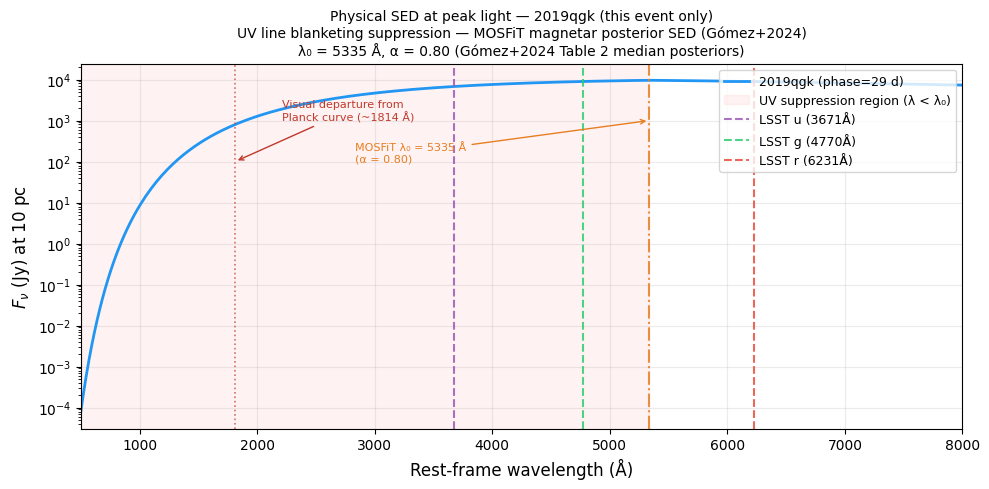

In [20]:
# ============================================================================
# CELL: SED at peak light — UV line blanketing suppression
# Shows physical SED Fnu vs rest-frame wavelength for one event at peak
# Illustrates why g-band fails at high z (UV suppression)
# ============================================================================
# Reload flags:
#   Templates  : NO — loads physical_templates.pkl directly
#   Population : NO
#   Mag grid   : NO
#   Kernel     : NO
#
# Toggles
EVENT_IDX  = 100   # index into sed_grid/names (0–264); 100 = 2019qgk
SHOW_ANNOT = True  # show suppression edge annotation

import joblib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# Load physical templates
tpl_path  = get_output_dir('SLSNe', subdir='shared') / 'physical_templates.pkl'
templates = joblib.load(tpl_path)
sg        = templates['sed_grid']
names     = templates['names']

# --- Select event and find peak phase ---
s         = sg[EVENT_IDX]
event_name = names[EVENT_IDX]
lam        = s['lam_rest_A']          # (500,) Angstroms
fnu        = s['Fnu_abs']             # (161, 500) Jy at 10 pc
phase      = s['phase']               # (161,) days

total_flux = fnu.sum(axis=1)
peak_idx   = np.argmax(total_flux)
peak_phase = phase[peak_idx]
fnu_peak   = fnu[peak_idx, :]        # (500,) Jy at peak

# --- Load MOSFiT posterior parameters for this event ---
params_path = get_output_dir('SLSNe').parent / 'all_events' / 'allparameter.csv'
params_df   = pd.read_csv(params_path)
event_row   = params_df[params_df['name'] == event_name]
if len(event_row) > 0:
    mosfit_lambda0 = float(event_row['cutoff_wavelength_med'].iloc[0])
    mosfit_alpha   = float(event_row['alpha_med'].iloc[0])
else:
    mosfit_lambda0 = None
    mosfit_alpha   = None
    print(f'Warning: {event_name} not found in allparameter.csv')

# --- Visual suppression edge: wavelength where flux drops to 10%
#     of optical mean. This is NOT the MOSFiT lambda_0 parameter —
#     it is the observed departure from the Planck curve. ---
opt_mask   = (lam >= 3000) & (lam < 8000)
opt_mean   = fnu_peak[opt_mask].mean()
supp_candidates = lam[(fnu_peak < 0.1 * opt_mean) & (lam < 4000)]
supp_edge  = supp_candidates.max() if len(supp_candidates) > 0 else None

# --- LSST filter centers (Angstroms) ---
lsst_centers = {
    'u': 3671,
    'g': 4770,
    'r': 6231,
}
lsst_colors = {'u': '#9b59b6', 'g': '#2ecc71', 'r': '#e74c3c'}

# --- Plot ---
LAM_MIN, LAM_MAX = 500, 8000
mask_plot = (lam >= LAM_MIN) & (lam <= LAM_MAX)

fig, ax = plt.subplots(figsize=(10, 5))

# SED line
ax.semilogy(lam[mask_plot], fnu_peak[mask_plot],
            color='#2196F3', lw=2.0,
            label=f'{event_name} (phase={peak_phase:.0f} d)')

# UV suppression shaded region — extends to MOSFiT lambda_0
# Everything blueward of lambda_0 is suppressed by the power law
supp_max = mosfit_lambda0 if mosfit_lambda0 is not None else 3000
ax.axvspan(LAM_MIN, supp_max, color='#ffcccc', alpha=0.25,
           label=f'UV suppression region (λ < λ₀)')

# LSST filter center lines
for fname, fcen in lsst_centers.items():
    ax.axvline(fcen, color=lsst_colors[fname], lw=1.5,
               ls='--', alpha=0.85, label=f'LSST {fname} ({fcen}Å)')

if SHOW_ANNOT:
    # Annotation 1: visual departure from Planck curve
    if supp_edge is not None:
        ax.axvline(supp_edge, color='#c0392b', lw=1.2, ls=':', alpha=0.7)
        ax.annotate(
            f'Visual departure from\nPlanck curve (~{supp_edge:.0f} Å)',
            xy=(supp_edge, 1e2),
            xytext=(supp_edge + 400, 1e3),
            fontsize=8, color='#c0392b',
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.0),
        )

    # Annotation 2: MOSFiT lambda_0
    if mosfit_lambda0 is not None:
        ax.axvline(mosfit_lambda0, color='#e67e22', lw=1.5, ls='-.', alpha=0.85)
        ax.annotate(
            f'MOSFiT λ₀ = {mosfit_lambda0:.0f} Å\n(α = {mosfit_alpha:.2f})',
            xy=(mosfit_lambda0, 1e3),
            xytext=(mosfit_lambda0 - 2500, 1e2),
            fontsize=8, color='#e67e22',
            arrowprops=dict(arrowstyle='->', color='#e67e22', lw=1.0),
        )

ax.set_xlim(LAM_MIN, LAM_MAX)
ax.set_xlabel('Rest-frame wavelength (Å)', fontsize=12)
ax.set_ylabel(r'$F_\nu$ (Jy) at 10 pc', fontsize=12)
ax.set_title(
    f'Physical SED at peak light — {event_name} (this event only)\n'
    f'UV line blanketing suppression — MOSFiT magnetar posterior SED '
    f'(Gómez+2024)\n'
    f'λ₀ = {mosfit_lambda0:.0f} Å, α = {mosfit_alpha:.2f} '
    f'(Gómez+2024 Table 2 median posteriors)',
    fontsize=10
)
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.25)

plt.tight_layout()
out_fig = get_output_dir('SLSNe') / f'sed_peak_suppression_{event_name}.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
print(f'Saved: {out_fig.name}')
print(f'Event: {event_name}')
print(f'MOSFiT lambda_0 = {mosfit_lambda0:.1f} A, alpha = {mosfit_alpha:.4f}')
print(f'Visual departure edge = {supp_edge:.0f} A' if supp_edge else 'No visual edge found')
plt.show()

Saved: gband_cliff_2019qgk.png


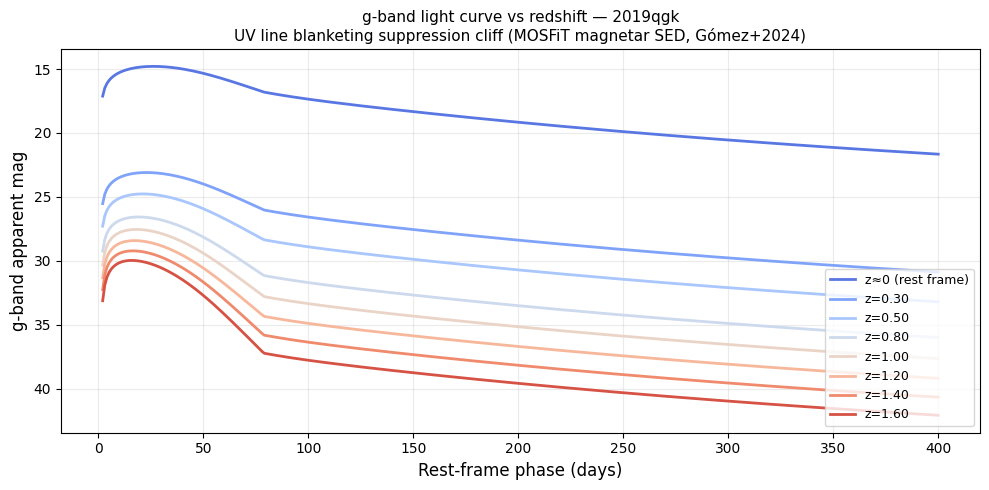

In [15]:
# ============================================================================
# CELL: g-band light curve at multiple redshifts — UV suppression cliff
# Shows how line blanketing suppresses g-band as SED redshifts into UV
# One line per redshift, shape-aligned (DM offset removed)
# ============================================================================
# Reload flags:
#   Templates  : NO — loads physical_templates.pkl directly
#   Population : NO
#   Mag grid   : NO
#   Kernel     : NO
#
# Toggles
EVENT_IDX    = 100                   # 2019qgk — same event as SED plot
REDSHIFTS    = [0.01, 0.3, 0.5, 0.8, 1.0, 1.2, 1.4, 1.6]
ALIGN_CURVES = False                  # remove DM vertical offset, show shape only

import joblib
import numpy as np
import matplotlib.pyplot as plt
from py_files.slsn_metrics.model import synthesize_mag_at_z

# Load physical templates
tpl_path   = get_output_dir('SLSNe', subdir='shared') / 'physical_templates.pkl'
templates  = joblib.load(tpl_path)
sg         = templates['sed_grid']
names      = templates['names']

event_name = names[EVENT_IDX]
sed_grid   = sg[EVENT_IDX]
phases     = np.array(sed_grid['phase'])   # (161,) rest-frame days

# Colors from blue (low-z) to red (high-z)
z_colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(REDSHIFTS)))

fig, ax = plt.subplots(figsize=(10, 5))

for zi, (z, col) in enumerate(zip(REDSHIFTS, z_colors)):
    mags = np.array([
        synthesize_mag_at_z(sed_grid, float(ph), z, 'g')
        for ph in phases
    ])

    valid = np.isfinite(mags)
    if valid.sum() < 3:
        print(f'[skip] z={z:.2f} — fewer than 3 finite magnitudes')
        continue

    ph_plot  = phases[valid]
    mag_plot = mags[valid]

    # Align curves vertically by subtracting mean — isolates shape
    if ALIGN_CURVES:
        mag_plot = mag_plot - np.nanmean(mag_plot)

    zlabel = 'z≈0 (rest frame)' if z < 0.05 else f'z={z:.2f}'
    ax.plot(ph_plot, mag_plot,
            color=col, lw=2.0, label=zlabel)

ax.invert_yaxis()
ax.set_xlabel('Rest-frame phase (days)', fontsize=12)
ylabel = 'Δg-band mag (shape only, DM removed)' if ALIGN_CURVES else 'g-band apparent mag'
ax.set_ylabel(ylabel, fontsize=12)
ax.set_title(
    f'g-band light curve vs redshift — {event_name}\n'
    f'UV line blanketing suppression cliff (MOSFiT magnetar SED, Gómez+2024)',
    fontsize=11
)
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.25)

plt.tight_layout()
out_fig = get_output_dir('SLSNe') / f'gband_cliff_{event_name}.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
print(f'Saved: {out_fig.name}')
plt.show()

Event: 2019qgk | Peak phase: 29.0 days


Valid redshift points: 36/36
Divergence point (>0.5 mag excess): z=0.31
Saved: gband_cliff_vs_z_2019qgk.png


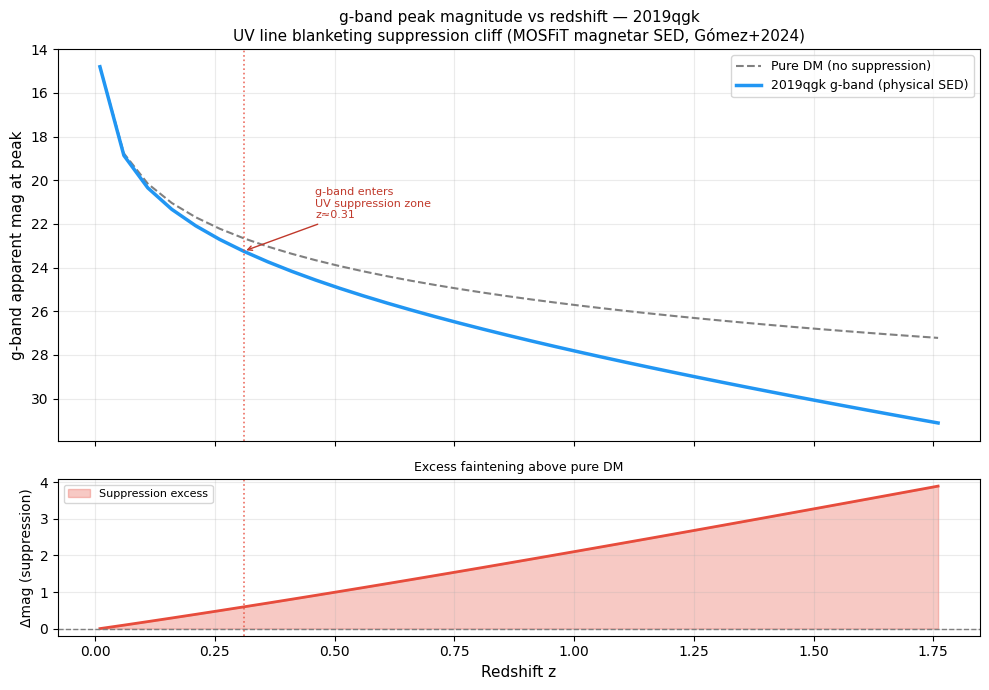

The divergence at z=0.31 means g-band is sampling rest-frame ~3670Å at that point. From the SED plot, the suppression edge for 2019qgk was at ~1814Å.
So this divergence at z=0.31 is not the hard UV suppression floor — it's the color gradient of the SED in the 3000–4000Å range (the SED is already declining toward UV before hitting the suppression floor).
The hard floor suppression dominates at higher z. 


In [16]:
# ============================================================================
# CELL: g-band peak magnitude vs redshift — UV suppression cliff
# X axis: redshift z (fine grid)
# Y axis: g-band apparent mag at peak light for one event
# Bottom panel: residual Δmag = observed - pure DM (suppression signal)
# ============================================================================
# Reload flags:
#   Templates  : NO — uses templates already loaded above
#   Population : NO
#   Mag grid   : NO
#   Kernel     : NO
#
# Toggles
EVENT_IDX = 100                        # 2019qgk
REDSHIFTS = np.arange(0.01, 1.8, 0.05)

from astropy.cosmology import Planck18 as cosmo
import astropy.units as u

# --- Find peak phase ---
sed_grid   = sg[EVENT_IDX]
event_name = names[EVENT_IDX]
phases     = np.array(sed_grid['phase'])
peak_phase = phases[np.argmax(np.array(sed_grid['Fnu_abs']).sum(axis=1))]
print(f'Event: {event_name} | Peak phase: {peak_phase:.1f} days')

# --- Synthesize g-band mag at peak across redshift grid ---
peak_mags = []
for z in REDSHIFTS:
    m = synthesize_mag_at_z(sed_grid, float(peak_phase), z, 'g')
    peak_mags.append(m)
peak_mags = np.array(peak_mags)

valid = np.isfinite(peak_mags)
print(f'Valid redshift points: {valid.sum()}/{len(REDSHIFTS)}')

# --- Pure DM reference anchored to first valid point ---
DM_ref = np.array([
    5 * np.log10(cosmo.luminosity_distance(z).to_value(u.pc) / 10.0)
    for z in REDSHIFTS
])
offset         = peak_mags[valid][0] - DM_ref[valid][0]
DM_ref_anchored = DM_ref + offset

# --- Residual: how much fainter than pure DM ---
residual = peak_mags - DM_ref_anchored   # positive = fainter than DM alone

# --- Find divergence point: first z where residual > 0.5 mag ---
div_candidates = REDSHIFTS[valid][residual[valid] > 0.5]
div_z = div_candidates[0] if len(div_candidates) > 0 else None
print(f'Divergence point (>0.5 mag excess): z={div_z:.2f}' if div_z else 'No divergence found')

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(10, 7),
                         gridspec_kw={'height_ratios': [3, 1.2]},
                         sharex=True)

# Top panel — mag vs z
ax = axes[0]
ax.plot(REDSHIFTS[valid], DM_ref_anchored[valid],
        color='gray', lw=1.5, ls='--', label='Pure DM (no suppression)')
ax.plot(REDSHIFTS[valid], peak_mags[valid],
        color='#2196F3', lw=2.5, label=f'{event_name} g-band (physical SED)')

# Divergence annotation
if div_z is not None:
    div_mag = peak_mags[np.argmin(np.abs(REDSHIFTS - div_z))]
    ax.axvline(div_z, color='#e74c3c', lw=1.2, ls=':', alpha=0.8)
    ax.annotate(
        f'g-band enters\nUV suppression zone\nz≈{div_z:.2f}',
        xy=(div_z, div_mag),
        xytext=(div_z + 0.15, div_mag - 1.5),
        fontsize=8, color='#c0392b',
        arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.0),
    )

ax.invert_yaxis()
ax.set_ylabel('g-band apparent mag at peak', fontsize=11)
ax.set_title(
    f'g-band peak magnitude vs redshift — {event_name}\n'
    f'UV line blanketing suppression cliff (MOSFiT magnetar SED, Gómez+2024)',
    fontsize=11
)
ax.legend(fontsize=9)
ax.grid(alpha=0.25)

# Bottom panel — residual
ax2 = axes[1]
ax2.fill_between(REDSHIFTS[valid], 0, residual[valid],
                 color='#e74c3c', alpha=0.3, label='Suppression excess')
ax2.plot(REDSHIFTS[valid], residual[valid],
         color='#e74c3c', lw=2.0)
ax2.axhline(0, color='gray', lw=1.0, ls='--')
if div_z is not None:
    ax2.axvline(div_z, color='#e74c3c', lw=1.2, ls=':', alpha=0.8)
ax2.set_xlabel('Redshift z', fontsize=11)
ax2.set_ylabel('Δmag (suppression)', fontsize=10)
ax2.set_title('Excess faintening above pure DM', fontsize=9)
ax2.grid(alpha=0.25)
ax2.legend(fontsize=8)

plt.tight_layout()
out_fig = get_output_dir('SLSNe') / f'gband_cliff_vs_z_{event_name}.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
print(f'Saved: {out_fig.name}')
plt.show()
print(f"The divergence at z=0.31 means g-band is sampling rest-frame ~3670Å at that point. From the SED plot, the suppression edge for 2019qgk was at ~1814Å.")
print(f"So this divergence at z=0.31 is not the hard UV suppression floor — it's the color gradient of the SED in the 3000–4000Å range (the SED is already declining toward UV before hitting the suppression floor).")
print(f"The hard floor suppression dominates at higher z. ")

Total templates:         265
CSVs found:              265
Pass ≥2 filters:         251 (94.7%)
Pass ≥15d baseline:       261 (98.5%)
Pass ≥2 detections:       263 (99.2%)
Has rise evidence:       261 (98.5%)
Pass ALL criteria:       250 (94.3%)

Saved: v1_catalog_coverage_completeness.png


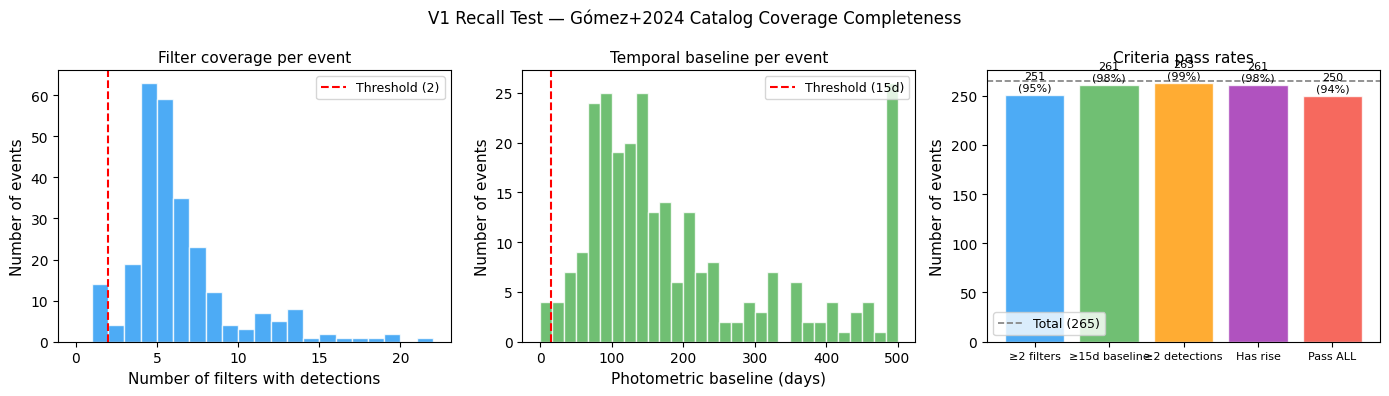


Events failing ALL criteria:
     name  n_filters  baseline_days  n_det  has_rise
   1999bz          1       0.000000      1     False
   2011ep          1      73.119873     22      True
   2014bl          1     404.119873     40      True
  2017beq          2      12.273710      3      True
  2017hbx          1     134.977359      7     False
  2017jan          1     886.743590     71      True
CSS160710          1      49.080070     29      True
iPTF13bjz          1      21.111000     18      True
 LSQ14fxj          1       0.000000      1     False
MLS121104          1       0.120118      4      True
 OGLE15sd          1     133.858440     46      True
 OGLE15xl          1     106.895410     29      True
 OGLE15xx          1      67.747120     19      True
OGLE16dmu          1     238.586770     58      True
 PTF10bjp          1      91.848000     22      True


In [17]:
# ============================================================================
# CELL V1: Recall test — catalog coverage completeness check
# For each Gómez+2024 event, assess whether observed photometry
# has sufficient coverage to in-principle pass detection criteria
# independent of LSST depth
# ============================================================================
# IMPORTANT CAVEAT — Physical track vs GP track interpretation:
#
# This recall test validates the *observed per-event CSVs* (Gómez+2024),
# which are the direct input to the GP template system.
#
# For the PHYSICAL track, templates are derived from MOSFiT posterior
# parameters, not directly from the CSVs. Physical templates:
#   - Cover post-peak phases only (day 1–400, no pre-peak rise)
#   - Extend to UV (500A) via the magnetar model
#   - Are well-sampled by construction (161 phases x 500 wavelengths)
#     regardless of observed CSV sparsity
#
# Therefore V1 for the physical track answers:
#   "Is the catalog input data quality sufficient for MOSFiT fitting?"
#   NOT "Are the physical templates themselves well-sampled?"
#
# The absence of pre-peak phases in physical templates is a known
# limitation — events detectable only during rise may be systematically
# missed. This connects to V3 (efficiency loss decomposition).
# ============================================================================
# Reload flags:
#   Templates  : NO
#   Population : NO
#   Mag grid   : NO
#   Kernel     : NO

import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from pathlib import Path

# --- Config ---
PER_EVENT_DIR = Path('output/per_event_files')
MIN_FILTERS   = 2      # Detect criterion: ≥2 filters
MIN_BASELINE  = 15     # days
MIN_DETECTIONS = 2     # minimum detected (non-UL) observations

# Load template names for index alignment check
import joblib
tpl       = joblib.load('output/SLSNe/shared/physical_templates.pkl')
tpl_names = tpl['names']   # 265 names in template order

# --- Loop over all 265 base CSVs ---
results = []
for name in tpl_names:
    csv_path = PER_EVENT_DIR / f'{name}.csv'
    if not csv_path.exists():
        results.append({
            'name': name, 'found': False,
            'n_det': 0, 'n_filters': 0,
            'baseline_days': 0, 'has_rise': False,
            'pass_filters': False, 'pass_baseline': False,
            'pass_ndet': False, 'pass_all': False,
        })
        continue

    df = pd.read_csv(csv_path)

    # Only use non-upper-limit detections
    det = df[df['detected'] == 1].copy()
    n_det     = len(det)
    n_filters = det['filter'].nunique() if n_det > 0 else 0
    baseline  = (det['mjd'].max() - det['mjd'].min()) if n_det > 1 else 0

    # Rise check: any filter with ≥2 detections where mag decreases (brightens)
    has_rise = False
    if n_det >= 2:
        for filt, grp in det.groupby('filter'):
            grp = grp.sort_values('mjd')
            if len(grp) >= 2:
                # Brightening = magnitude decreasing
                if (grp['mag'].diff().dropna() < 0).any():
                    has_rise = True
                    break

    pass_filters  = n_filters >= MIN_FILTERS
    pass_baseline = baseline  >= MIN_BASELINE
    pass_ndet     = n_det     >= MIN_DETECTIONS
    pass_all      = pass_filters and pass_baseline and pass_ndet

    results.append({
        'name':          name,
        'found':         True,
        'n_det':         n_det,
        'n_filters':     n_filters,
        'baseline_days': baseline,
        'has_rise':      has_rise,
        'pass_filters':  pass_filters,
        'pass_baseline': pass_baseline,
        'pass_ndet':     pass_ndet,
        'pass_all':      pass_all,
    })

df_v1 = pd.DataFrame(results)

# --- Summary ---
n_total    = len(df_v1)
n_found    = df_v1['found'].sum()
n_pass_all = df_v1['pass_all'].sum()
n_pass_filt= df_v1['pass_filters'].sum()
n_pass_base= df_v1['pass_baseline'].sum()
n_has_rise = df_v1['has_rise'].sum()

print(f'Total templates:         {n_total}')
print(f'CSVs found:              {n_found}')
print(f'Pass ≥{MIN_FILTERS} filters:         {n_pass_filt} ({100*n_pass_filt/n_total:.1f}%)')
print(f'Pass ≥{MIN_BASELINE}d baseline:       {n_pass_base} ({100*n_pass_base/n_total:.1f}%)')
print(f'Pass ≥{MIN_DETECTIONS} detections:       {df_v1["pass_ndet"].sum()} ({100*df_v1["pass_ndet"].sum()/n_total:.1f}%)')
print(f'Has rise evidence:       {n_has_rise} ({100*n_has_rise/n_total:.1f}%)')
print(f'Pass ALL criteria:       {n_pass_all} ({100*n_pass_all/n_total:.1f}%)')

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Filter count distribution
axes[0].hist(df_v1['n_filters'], bins=range(0, df_v1['n_filters'].max()+2),
             color='#2196F3', edgecolor='white', alpha=0.8)
axes[0].axvline(MIN_FILTERS, color='red', ls='--', lw=1.5,
                label=f'Threshold ({MIN_FILTERS})')
axes[0].set_xlabel('Number of filters with detections', fontsize=11)
axes[0].set_ylabel('Number of events', fontsize=11)
axes[0].set_title('Filter coverage per event', fontsize=11)
axes[0].legend(fontsize=9)

# Baseline distribution
axes[1].hist(df_v1['baseline_days'].clip(upper=500), bins=30,
             color='#4CAF50', edgecolor='white', alpha=0.8)
axes[1].axvline(MIN_BASELINE, color='red', ls='--', lw=1.5,
                label=f'Threshold ({MIN_BASELINE}d)')
axes[1].set_xlabel('Photometric baseline (days)', fontsize=11)
axes[1].set_ylabel('Number of events', fontsize=11)
axes[1].set_title('Temporal baseline per event', fontsize=11)
axes[1].legend(fontsize=9)

# Pass/fail summary bar
categories = ['≥2 filters', f'≥{MIN_BASELINE}d baseline',
              f'≥{MIN_DETECTIONS} detections', 'Has rise', 'Pass ALL']
counts     = [n_pass_filt, n_pass_base,
              int(df_v1['pass_ndet'].sum()), n_has_rise, n_pass_all]
colors     = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']
bars = axes[2].bar(categories, counts, color=colors, alpha=0.8, edgecolor='white')
axes[2].axhline(n_total, color='gray', ls='--', lw=1.2, label=f'Total ({n_total})')
for bar, count in zip(bars, counts):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{count}\n({100*count/n_total:.0f}%)',
                 ha='center', va='bottom', fontsize=8)
axes[2].set_ylabel('Number of events', fontsize=11)
axes[2].set_title('Criteria pass rates', fontsize=11)
axes[2].legend(fontsize=9)
axes[2].tick_params(axis='x', labelsize=8)

plt.suptitle('V1 Recall Test — Gómez+2024 Catalog Coverage Completeness', fontsize=12)
plt.tight_layout()

out_fig = get_output_dir('SLSNe') / 'v1_catalog_coverage_completeness.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
print(f'\nSaved: {out_fig.name}')
plt.show()
# Show the 15 events that fail all criteria
failed = df_v1[~df_v1['pass_all']][['name','n_filters','baseline_days','n_det','has_rise']]
print('\nEvents failing ALL criteria:')
print(failed.to_string(index=False))